# Member 4 — Deep Learning & Anomaly Detection

## Industrial Predictive Maintenance & Failure Prevention

This notebook develops the Deep Learning component of the predictive maintenance system using the leakage-safe, feature-ready dataset prepared in the previous project stages.

The Deep Learning track consists of two complementary approaches:

1. **Multilayer Perceptron (MLP)** — a supervised neural network for predicting machine failure probability.
2. **Autoencoder** — an unsupervised neural network for detecting abnormal machine operating conditions through reconstruction error.

The notebook preserves the same feature set, target definition, stratified 70/15/15 train-validation-test split, and random state established in the Classical Machine Learning stage. This ensures that the Deep Learning models are evaluated under the same experimental conditions and can be compared fairly with the classical models.

The workflow includes model preparation, training, regularization, learning-rate control, training-curve analysis, failure prediction, anomaly scoring, threshold selection, evaluation, and final supervised-vs-unsupervised comparison.

> **Leakage Safety:** The failure-mode variables `twf`, `hdf`, `pwf`, `osf`, and `rnf` are not used as model inputs because they directly contribute to the definition of `machine_failure`.

In [1]:
# ============================================================
# DEEP LEARNING ENVIRONMENT
# ============================================================

import os
import random
import warnings

# ============================================================
# REPRODUCIBILITY SETTINGS
# Must be configured before TensorFlow model training
# ============================================================

RANDOM_STATE = 42

os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    roc_curve
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

warnings.filterwarnings("ignore")

# Reproducible random initialization
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.keras.utils.set_random_seed(RANDOM_STATE)

# Enable deterministic TensorFlow operations
tf.config.experimental.enable_op_determinism()

print("TensorFlow version:", tf.__version__)
print("Random state:", RANDOM_STATE)
print("Deterministic execution enabled.")
print("Environment initialized successfully.")

TensorFlow version: 2.20.0
Random state: 42
Deterministic execution enabled.
Environment initialized successfully.


## 1. Load the Feature-Ready Dataset

The Deep Learning stage starts directly from the final feature-ready dataset produced by the Data Engineering and EDA stage.

No additional feature engineering or preprocessing is performed here because these operations have already been completed and validated upstream. Reusing the same dataset also guarantees consistency between the Classical Machine Learning and Deep Learning experiments.

The dataset contains the leakage-safe operating and engineered features together with the binary target `machine_failure`.

In [2]:
# ============================================================
# LOAD FEATURE-READY DATASET FROM COLAB PATH
# ============================================================

DATA_PATH = "/content/ai4i2020_feature_ready.csv"
SCALER_PATH = "/content/feature_scaler.pkl"
df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

df.head()

Dataset loaded successfully.
Dataset shape: (10000, 17)

Columns:
['air_temperature_k', 'process_temperature_k', 'rotational_speed_rpm', 'torque_nm', 'tool_wear_min', 'machine_failure', 'type_H', 'type_L', 'type_M', 'temp_diff_k', 'power_w', 'tool_wear_torque_product', 'speed_torque_ratio', 'wear_early_life', 'wear_mid_life', 'wear_wear_window', 'wear_beyond_240']


,air_temperature_k,process_temperature_k,rotational_speed_rpm,torque_nm,tool_wear_min,machine_failure,type_H,type_L,type_M,temp_diff_k,power_w,tool_wear_torque_product,speed_torque_ratio,wear_early_life,wear_mid_life,wear_wear_window,wear_beyond_240
0,298.1,308.6,1551,42.8,0,0,0,0,1,10.5,6951.590560,0.0,36.238318,1,0,0,0
1,298.2,308.7,1408,46.3,3,0,0,1,0,10.5,6826.722724,138.9,30.410367,1,0,0,0
2,298.1,308.5,1498,49.4,5,0,0,1,0,10.4,7749.387543,247.0,30.323887,1,0,0,0
3,298.2,308.6,1433,39.5,7,0,0,1,0,10.4,5927.504659,276.5,36.278481,1,0,0,0
4,298.2,308.7,1408,40.0,9,0,0,1,0,10.5,5897.816608,360.0,35.200000,1,0,0,0


## 2. Data Integrity and Deep Learning Handoff Verification

Before constructing the neural networks, the feature-ready dataset is verified to ensure that the Deep Learning stage receives exactly the same modeling data used by the previous Machine Learning stages.

This verification checks:

- Dataset dimensions.
- Missing and duplicate records.
- Presence of the expected target.
- Absence of known leakage variables.
- Final feature count and names.

This is a validation step rather than a new preprocessing stage. No upstream data transformations are repeated or modified.

In [3]:
# ============================================================
# VERIFY DATA HANDOFF
# ============================================================

leakage_cols = ["twf", "hdf", "pwf", "osf", "rnf"]

print("Dataset shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Target available:", "machine_failure" in df.columns)

present_leakage_cols = [
    col for col in leakage_cols
    if col in df.columns
]

print("Leakage columns present:", present_leakage_cols)

if present_leakage_cols:
    raise ValueError(
        f"Leakage columns detected: {present_leakage_cols}"
    )

print("\nDeep Learning handoff verification passed successfully.")

Dataset shape: (10000, 17)
Missing values: 0
Duplicate rows: 0
Target available: True
Leakage columns present: []

Deep Learning handoff verification passed successfully.


### Observation

The feature-ready dataset was loaded successfully with **10,000 observations and 17 columns**.

After separating the target, the modeling matrix contains **16 leakage-safe predictive features**, while `machine_failure` is retained as the binary target.

The dataset passed the Deep Learning handoff verification successfully:

- No missing values were detected.
- No duplicated observations were found.
- The target variable is available.
- None of the known leakage columns (`twf`, `hdf`, `pwf`, `osf`, `rnf`) are present in the feature set.

This confirms that the Deep Learning stage is operating on the same validated, feature-ready representation produced by the upstream pipeline.

## 3. Feature-Target Separation

The binary target `machine_failure` is separated from the predictive features using the same variable names established in the Classical Machine Learning notebook.

- `X` contains the leakage-safe machine operating and engineered features.
- `y` contains the binary machine-failure target.

Maintaining the same feature definition is essential for a valid Classical ML vs Deep Learning comparison.

In [4]:
# ============================================================
# SEPARATE FEATURES AND TARGET
# ============================================================

X = df.drop(columns=["machine_failure"])
y = df["machine_failure"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeature columns:")
print(X.columns.tolist())

print("\nTarget distribution:")
print(y.value_counts())

print("\nTarget percentages:")
print((y.value_counts(normalize=True) * 100).round(2))

X shape: (10000, 16)
y shape: (10000,)

Feature columns:
['air_temperature_k', 'process_temperature_k', 'rotational_speed_rpm', 'torque_nm', 'tool_wear_min', 'type_H', 'type_L', 'type_M', 'temp_diff_k', 'power_w', 'tool_wear_torque_product', 'speed_torque_ratio', 'wear_early_life', 'wear_mid_life', 'wear_wear_window', 'wear_beyond_240']

Target distribution:
machine_failure
0    9661
1     339
Name: count, dtype: int64

Target percentages:
machine_failure
0    96.61
1     3.39
Name: proportion, dtype: float64


### Observation

The target distribution is strongly imbalanced.

- **Normal machines (`machine_failure = 0`)**: 9,661 observations (**96.61%**)
- **Failed machines (`machine_failure = 1`)**: 339 observations (**3.39%**)

Therefore, overall accuracy would not be an appropriate primary metric because a model could achieve high accuracy simply by favoring the majority class.

For the Deep Learning stage, particular attention will be given to **recall, precision, F1-score, PR-AUC, and false-negative behavior**, since missed machine failures are especially important in the predictive-maintenance context.

## 4. Reproduce the Established Train / Validation / Test Split

To ensure a fair comparison with the Classical Machine Learning models, the exact same stratified split strategy is reproduced:

- **70% Training Set** — used to train the neural networks.
- **15% Validation Set** — used for model selection, training control, and threshold-related decisions.
- **15% Test Set** — reserved for final unbiased evaluation.

Stratification preserves the rare machine-failure proportion across all subsets, which is particularly important because the target is strongly imbalanced.

The fixed `RANDOM_STATE = 42` reproduces the same observations assigned to each subset in the previous modeling stages.

In [5]:
# ============================================================
# STRATIFIED TRAIN / VALIDATION / TEST SPLIT
# ============================================================

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_STATE
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=RANDOM_STATE
)

print(
    f"Train:      {X_train.shape[0]} rows | "
    f"failure rate: {y_train.mean():.4f}"
)

print(
    f"Validation: {X_val.shape[0]} rows | "
    f"failure rate: {y_val.mean():.4f}"
)

print(
    f"Test:       {X_test.shape[0]} rows | "
    f"failure rate: {y_test.mean():.4f}"
)

Train:      7000 rows | failure rate: 0.0339
Validation: 1500 rows | failure rate: 0.0340
Test:       1500 rows | failure rate: 0.0340


### Observation

The stratified splitting procedure successfully preserved the original failure proportion across all subsets.

- Training set: **7,000 observations**, failure rate ≈ **3.39%**
- Validation set: **1,500 observations**, failure rate ≈ **3.40%**
- Test set: **1,500 observations**, failure rate ≈ **3.40%**

The nearly identical class proportions confirm that stratification was applied correctly.

Maintaining the same 70/15/15 split used in the Classical Machine Learning stage provides a consistent experimental basis for the final ML-vs-DL comparison.

## 5. Reuse the Established Feature Scaling

Neural networks are sensitive to differences in feature magnitude because optimization is performed through gradient-based learning. Therefore, the continuous numerical features must be standardized before training the MLP and Autoencoder.

To maintain complete consistency with the Classical Machine Learning pipeline, the same numerical feature list and the same training-only scaling strategy are retained.

The scaler is fitted exclusively on the training data. The learned transformation is then applied to the validation and test sets. This prevents information from the validation or test sets from influencing the training process.

In [6]:
# ============================================================
# LOAD AND APPLY EXISTING FEATURE SCALER
# ============================================================

numeric_cols = [
    "air_temperature_k",
    "process_temperature_k",
    "rotational_speed_rpm",
    "torque_nm",
    "tool_wear_min",
    "temp_diff_k",
    "power_w",
    "tool_wear_torque_product",
    "speed_torque_ratio"
]

scaler = joblib.load("feature_scaler.pkl")

X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.transform(
    X_train[numeric_cols]
)

X_val_scaled[numeric_cols] = scaler.transform(
    X_val[numeric_cols]
)

X_test_scaled[numeric_cols] = scaler.transform(
    X_test[numeric_cols]
)

print("Training shape:", X_train_scaled.shape)
print("Validation shape:", X_val_scaled.shape)
print("Test shape:", X_test_scaled.shape)

X_train_scaled.head()

Training shape: (7000, 16)
Validation shape: (1500, 16)
Test shape: (1500, 16)


,air_temperature_k,process_temperature_k,rotational_speed_rpm,torque_nm,tool_wear_min,type_H,type_L,type_M,temp_diff_k,power_w,tool_wear_torque_product,speed_torque_ratio,wear_early_life,wear_mid_life,wear_wear_window,wear_beyond_240
1888,-1.105779,-1.759415,2.012835,-1.569298,0.334742,0,0,1,-0.392635,-1.346709,-0.412341,1.347484,0,1,0,0
4858,1.840492,1.547973,-1.055557,1.099287,-0.041084,0,1,0,-1.393563,0.860509,0.371765,-0.645788,0,1,0,0
8990,-1.405400,-1.421926,-0.256554,-0.160045,0.600952,0,1,0,0.708385,-0.260460,0.460547,-0.167700,0,1,0,0
4901,1.790556,1.547973,0.503608,-0.759727,1.806727,0,0,1,-1.293470,-0.702209,1.032232,0.271893,0,0,1,0
7957,0.442262,1.277982,3.333409,-2.348885,-1.011967,1,0,0,1.008663,-2.413018,-1.268809,3.325553,1,0,0,0


### Observation

Feature scaling was applied successfully while preserving the original dataset dimensions:

- Training set: **(7000, 16)**
- Validation set: **(1500, 16)**
- Test set: **(1500, 16)**

The continuous numerical features are now standardized, while the binary encoded variables remain unchanged.

This representation is suitable for neural-network training because it prevents large-scale numerical features from dominating the gradient-based optimization process.

## 6. Class Imbalance Strategy for the MLP

The machine-failure target is highly imbalanced, with failures representing only about 3.4% of the observations.

Training a neural network without accounting for this imbalance could cause the model to favor the majority non-failure class and miss a large proportion of actual failures.

To address this issue without artificially generating synthetic observations, **class weighting** is used during MLP training.

The class weights are computed only from the training labels. Larger weight is assigned to the minority failure class, increasing the penalty when the neural network misclassifies an actual machine failure.

This approach preserves the original data distribution while making the learning objective more sensitive to the minority class.

In [7]:
# ============================================================
# COMPUTE CLASS WEIGHTS FOR MLP TRAINING
# ============================================================

classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight = {
    int(cls): float(weight)
    for cls, weight in zip(classes, class_weights)
}

print("Class weights:")
print(class_weight)

Class weights:
{0: 0.5175218098477007, 1: 14.767932489451477}


### Observation

The computed class weights confirm the severity of the target imbalance:

- **Normal class (0):** weight = **0.518**
- **Failure class (1):** weight = **14.768**

The failure class therefore receives a substantially larger training weight because it represents only 3.39% of the dataset.

During MLP training, errors involving actual machine failures will contribute much more strongly to the loss function than errors involving normal machines. This encourages the network to pay greater attention to the minority failure class and helps reduce the risk of excessive false negatives.

Class weighting is applied only during model training; it does not alter the validation or test distributions.

### 6.2 MLP Hyperparameter Experiments and Model Selection

Before constructing the final MLP, a controlled hyperparameter experiment is performed to identify a suitable neural-network configuration using the validation set only.

The experiment evaluates a small set of candidate architectures while varying:

- Hidden-layer structure.
- Dropout rate.
- Learning rate.
- Batch size.

All candidate models use:

- The same leakage-safe standardized training features.
- The same stratified training and validation partitions.
- The same class-weighting strategy.
- Binary cross-entropy loss.
- Adam optimization.
- Early Stopping based on validation PR-AUC.

Because the machine-failure target is strongly imbalanced, **validation PR-AUC** is used as the primary model-selection criterion.

The test set is not used during hyperparameter selection and remains completely untouched until the final selected MLP is evaluated.

In [8]:
# ============================================================
# MLP HYPERPARAMETER EXPERIMENTS
# ============================================================

mlp_experiments = [
    {
        "name": "Config A",
        "hidden_layers": [32, 16],
        "dropout_rate": 0.20,
        "learning_rate": 0.001,
        "batch_size": 64
    },

    {
        "name": "Config B",
        "hidden_layers": [64, 32, 16],
        "dropout_rate": 0.30,
        "learning_rate": 0.001,
        "batch_size": 64
    },

    {
        "name": "Config C",
        "hidden_layers": [128, 64, 32],
        "dropout_rate": 0.40,
        "learning_rate": 0.0005,
        "batch_size": 64
    },

    {
        "name": "Config D",
        "hidden_layers": [64, 32],
        "dropout_rate": 0.30,
        "learning_rate": 0.0005,
        "batch_size": 32
    }
]

print("MLP Hyperparameter Configurations")
print("=" * 70)

for config in mlp_experiments:

    print(
        f"{config['name']} | "
        f"Layers: {config['hidden_layers']} | "
        f"Dropout: {config['dropout_rate']} | "
        f"LR: {config['learning_rate']} | "
        f"Batch: {config['batch_size']}"
    )

MLP Hyperparameter Configurations
Config A | Layers: [32, 16] | Dropout: 0.2 | LR: 0.001 | Batch: 64
Config B | Layers: [64, 32, 16] | Dropout: 0.3 | LR: 0.001 | Batch: 64
Config C | Layers: [128, 64, 32] | Dropout: 0.4 | LR: 0.0005 | Batch: 64
Config D | Layers: [64, 32] | Dropout: 0.3 | LR: 0.0005 | Batch: 32


#### 6.2.1 Controlled MLP Hyperparameter Experiment

Each candidate configuration is trained under the same experimental conditions so that the comparison is fair and reproducible.

The following controls are kept constant across all experiments:

- The same standardized training and validation datasets.
- The same class weights.
- Binary cross-entropy loss.
- Adam optimization.
- Early Stopping based on validation PR-AUC.
- Learning-rate reduction when validation performance plateaus.
- A maximum of 60 epochs per candidate.

For each configuration, the best validation PR-AUC is recorded together with the corresponding validation recall, precision, loss, and best epoch.

The test set is not used during this experiment.

In [9]:
# ============================================================
# CONTROLLED MLP HYPERPARAMETER EXPERIMENT
# ============================================================

tuning_results = []

for config in mlp_experiments:

    print("\n" + "=" * 80)
    print(f"Training {config['name']}")
    print("=" * 80)

    # Reset Keras state between experiments
    keras.backend.clear_session()

    # Reproducibility
    random.seed(RANDOM_STATE)
    np.random.seed(RANDOM_STATE)
    tf.random.set_seed(RANDOM_STATE)

    input_dim = X_train_scaled.shape[1]

    tuning_model = keras.Sequential(
        name=f"mlp_{config['name'].replace(' ', '_').lower()}"
    )

    tuning_model.add(
        layers.Input(shape=(input_dim,))
    )

    # Add candidate hidden layers
    for i, units in enumerate(config["hidden_layers"]):

        tuning_model.add(
            layers.Dense(
                units,
                activation="relu"
            )
        )

        # Batch Normalization after the first hidden layer
        if i == 0:
            tuning_model.add(
                layers.BatchNormalization()
            )

        # Apply dropout after each hidden layer except the last one
        if i < len(config["hidden_layers"]) - 1:
            tuning_model.add(
                layers.Dropout(
                    config["dropout_rate"]
                )
            )

    # Binary classification output
    tuning_model.add(
        layers.Dense(
            1,
            activation="sigmoid"
        )
    )

    tuning_model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=config[
                "learning_rate"
            ]
        ),
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.Precision(
                name="precision"
            ),
            keras.metrics.Recall(
                name="recall"
            ),
            keras.metrics.AUC(
                curve="PR",
                name="pr_auc"
            )
        ]
    )

    # Fresh callbacks for every experiment
    tuning_early_stopping = EarlyStopping(
        monitor="val_pr_auc",
        mode="max",
        patience=6,
        restore_best_weights=True,
        verbose=0
    )

    tuning_reduce_lr = ReduceLROnPlateau(
        monitor="val_pr_auc",
        mode="max",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=0
    )

    tuning_history = tuning_model.fit(
        X_train_scaled,
        y_train,
        validation_data=(
            X_val_scaled,
            y_val
        ),
        epochs=60,
        batch_size=config[
            "batch_size"
        ],
        class_weight=class_weight,
        callbacks=[
            tuning_early_stopping,
            tuning_reduce_lr
        ],
        verbose=0
    )

    history_df_tuning = pd.DataFrame(
        tuning_history.history
    )

    best_idx = int(
        history_df_tuning[
            "val_pr_auc"
        ].idxmax()
    )

    result = {
        "Configuration":
            config["name"],

        "Hidden Layers":
            " → ".join(
                map(
                    str,
                    config[
                        "hidden_layers"
                    ]
                )
            ),

        "Dropout":
            config["dropout_rate"],

        "Learning Rate":
            config["learning_rate"],

        "Batch Size":
            config["batch_size"],

        "Best Epoch":
            best_idx + 1,

        "Best Val PR-AUC":
            history_df_tuning.loc[
                best_idx,
                "val_pr_auc"
            ],

        "Val Recall":
            history_df_tuning.loc[
                best_idx,
                "val_recall"
            ],

        "Val Precision":
            history_df_tuning.loc[
                best_idx,
                "val_precision"
            ],

        "Val Loss":
            history_df_tuning.loc[
                best_idx,
                "val_loss"
            ]
    }

    tuning_results.append(result)

    print(
        f"{config['name']} completed | "
        f"Best Val PR-AUC: "
        f"{result['Best Val PR-AUC']:.4f} | "
        f"Best Epoch: "
        f"{result['Best Epoch']}"
    )


mlp_tuning_results = pd.DataFrame(
    tuning_results
)

mlp_tuning_results = (
    mlp_tuning_results
    .sort_values(
        by="Best Val PR-AUC",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\nFinal Hyperparameter Experiment Results")
print("=" * 80)

display(
    mlp_tuning_results.round(4)
)


Training Config A
Config A completed | Best Val PR-AUC: 0.6563 | Best Epoch: 27

Training Config B
Config B completed | Best Val PR-AUC: 0.6317 | Best Epoch: 13

Training Config C
Config C completed | Best Val PR-AUC: 0.6278 | Best Epoch: 21

Training Config D
Config D completed | Best Val PR-AUC: 0.6304 | Best Epoch: 9

Final Hyperparameter Experiment Results


,Configuration,Hidden Layers,Dropout,Learning Rate,Batch Size,Best Epoch,Best Val PR-AUC,Val Recall,Val Precision,Val Loss
0,Config A,32 → 16,0.2,0.0010,64,27,0.6563,0.8627,0.3438,0.1713
1,Config B,64 → 32 → 16,0.3,0.0010,64,13,0.6317,0.8824,0.2922,0.2003
2,Config D,64 → 32,0.3,0.0005,32,9,0.6304,0.8627,0.2699,0.2207
3,Config C,128 → 64 → 32,0.4,0.0005,64,21,0.6278,0.8627,0.2651,0.2173


In [10]:
# ============================================================
# SELECT BEST MLP HYPERPARAMETER CONFIGURATION
# ============================================================

best_mlp_config_name = mlp_tuning_results.loc[
    0,
    "Configuration"
]

best_mlp_config = next(
    config
    for config in mlp_experiments
    if config["name"] == best_mlp_config_name
)

print("Selected MLP Configuration")
print("=" * 50)
print("Configuration:", best_mlp_config["name"])
print("Hidden layers:", best_mlp_config["hidden_layers"])
print("Dropout rate:", best_mlp_config["dropout_rate"])
print("Learning rate:", best_mlp_config["learning_rate"])
print("Batch size:", best_mlp_config["batch_size"])

Selected MLP Configuration
Configuration: Config A
Hidden layers: [32, 16]
Dropout rate: 0.2
Learning rate: 0.001
Batch size: 64


### 6.2.2 Hyperparameter Experiment Results and Model Selection

The controlled hyperparameter experiment evaluated multiple MLP configurations under the same leakage-safe training and validation framework. The candidate models varied in hidden-layer structure, dropout regularization, learning rate, and batch size while preserving identical data partitions and evaluation criteria.

Because machine failure is a highly imbalanced target, **validation PR-AUC** was used as the primary configuration-selection metric. This metric emphasizes performance on the minority failure class and provides a more informative assessment of precision-recall behavior than accuracy alone.

Based on the experimental results, **Config A** achieved the highest validation PR-AUC and was selected as the MLP configuration for the subsequent supervised Deep Learning pipeline.

#### Selected Configuration

| Parameter | Selected Value |
|---|---:|
| Configuration | **Config A** |
| Hidden Architecture | **32 → 16** |
| Dropout Rate | **0.20** |
| Learning Rate | **0.001** |
| Batch Size | **64** |
| Best Validation PR-AUC | **0.6563** |
| Best Epoch | **27** |

The selected architecture is relatively compact, indicating that increasing network depth and width did not improve validation PR-AUC under the evaluated configurations.

Most importantly, configuration selection was performed **exclusively using training and validation data**. The test set remained untouched throughout hyperparameter selection and was reserved for independent evaluation after all model-development decisions were completed.

## 7. Supervised Deep Learning — MLP Failure Classifier

A **Multilayer Perceptron (MLP)** is developed as the supervised Deep Learning component for machine-failure prediction using the leakage-safe, feature-ready industrial sensor data.

The AI4I dataset represents structured tabular observations rather than genuine temporal sequences. Therefore, a feed-forward MLP is more appropriate for the available data structure than sequence-specific architectures such as LSTM or GRU.

The network architecture is constructed dynamically from the configuration selected during the validation-based hyperparameter experiment.

### Selected MLP Architecture

**Input (16 Features) → Dense(32, ReLU) → Batch Normalization → Dropout(0.20) → Dense(16, ReLU) → Dense(1, Sigmoid)**

The architecture contains:

- **16 input features** representing the leakage-safe sensor and engineered predictors.
- **32-unit first hidden layer** with ReLU activation for nonlinear feature interaction learning.
- **Batch Normalization** to stabilize intermediate activations during optimization.
- **Dropout of 0.20** to provide regularization and reduce dependence on individual hidden units.
- **16-unit second hidden layer** with ReLU activation for higher-level representation learning.
- **Single sigmoid output neuron** producing the estimated probability of machine failure.

The selected configuration uses a learning rate of **0.001** and a batch size of **64**.

This MLP serves as the supervised Deep Learning failure-risk model and is subsequently evaluated against both the unsupervised Autoencoder anomaly detector and the established classical Machine Learning benchmark.

In [11]:
# ============================================================
# BUILD MLP FAILURE CLASSIFIER
# ============================================================

keras.backend.clear_session()

# Reproducibility
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

input_dim = X_train_scaled.shape[1]

mlp_model = keras.Sequential(
    [
        layers.Input(
            shape=(input_dim,)
        ),

        layers.Dense(
            best_mlp_config["hidden_layers"][0],
            activation="relu"
        ),

        layers.BatchNormalization(),

        layers.Dropout(
            best_mlp_config["dropout_rate"]
        ),

        layers.Dense(
            best_mlp_config["hidden_layers"][1],
            activation="relu"
        ),

        layers.Dropout(
            best_mlp_config["dropout_rate"]
        ),

        layers.Dense(
            best_mlp_config["hidden_layers"][2],
            activation="relu"
        ),

        layers.Dense(
            1,
            activation="sigmoid"
        )
    ],
    name="failure_prediction_mlp"
)

mlp_model.summary()

Selected configuration: Config A
Hidden layers: [32, 16]
Dropout rate: 0.2
Learning rate: 0.001
Batch size: 64


Model: "mlp_failure_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,217 (4.75 KB)

 Trainable params: 1,153 (4.50 KB)

 Non-trainable params: 64 (256.00 B)

## 8. MLP Compilation

The selected MLP is configured for binary machine-failure classification.

The model uses:

- **Binary Cross-Entropy** as the loss function because the target contains two classes.
- **Adam** as the optimizer for gradient-based parameter optimization.
- The learning rate selected during the hyperparameter experiment.

Because machine failures represent only a small proportion of the observations, overall accuracy is not used as the primary training metric.

Instead, the training process monitors:

- **Precision** — the proportion of predicted failures that are actual failures.
- **Recall** — the proportion of actual failures successfully detected.
- **PR-AUC** — the overall precision-recall trade-off across probability thresholds.

PR-AUC is particularly appropriate for this project because the target is strongly imbalanced and the minority failure class is operationally important.

In [12]:
# ============================================================
# COMPILE MLP
# ============================================================

mlp_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=best_mlp_config["learning_rate"]
    ),

    loss="binary_crossentropy",

    metrics=[
        keras.metrics.Precision(
            name="precision"
        ),

        keras.metrics.Recall(
            name="recall"
        ),

        keras.metrics.AUC(
            curve="PR",
            name="pr_auc"
        )
    ]
)

print("MLP compiled successfully.")
print(
    "Learning rate:",
    best_mlp_config["learning_rate"]
)

MLP compiled successfully.
Learning rate: 0.001


## 9. MLP Training Strategy and Regularization

The MLP is trained using the standardized training subset, while the validation subset is used to monitor generalization during optimization.

The test set remains untouched during training.

Several mechanisms are applied to improve training stability and reduce overfitting.

### Class Weighting

The previously calculated class weights are supplied during training so that errors involving the rare machine-failure class receive greater importance.

This improves sensitivity to actual failures without modifying the original class distribution.

### Dropout

Dropout regularization is included in the selected architecture to reduce excessive dependence on individual neurons and improve generalization.

### Batch Normalization

Batch Normalization is applied after the first hidden layer to stabilize intermediate activations and support more consistent optimization.

### Early Stopping

Training is monitored using **validation PR-AUC**.

If validation PR-AUC does not improve for eight consecutive epochs, training is stopped automatically and the weights from the best-performing epoch are restored.

### Learning-Rate Reduction

If validation PR-AUC temporarily stops improving, the learning rate is reduced by a factor of 0.5.

This allows the optimizer to make progressively smaller updates and refine the learned solution.

In [13]:
# ============================================================
# MLP TRAINING CALLBACKS
# ============================================================

mlp_early_stopping = EarlyStopping(
    monitor="val_pr_auc",
    mode="max",
    patience=8,
    restore_best_weights=True,
    verbose=1
)

mlp_reduce_lr = ReduceLROnPlateau(
    monitor="val_pr_auc",
    mode="max",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

print("MLP training callbacks configured successfully.")

MLP training callbacks configured successfully.


## 10. MLP Training

The selected **Config A** Multilayer Perceptron is now trained using the leakage-safe training partition and the class-weighting strategy defined previously.

Because the machine-failure target is highly imbalanced, class weights are incorporated during training so that minority failure observations contribute more strongly to the optimization process without altering the natural validation or test distributions.

The training procedure combines several mechanisms designed to improve generalization and training stability:

- **Binary Cross-Entropy Loss** for binary machine-failure classification.
- **Class-weighted optimization** to increase sensitivity to the minority failure class.
- **Early Stopping** based on validation PR-AUC to prevent unnecessary training after generalization performance stops improving.
- **ReduceLROnPlateau** to decrease the learning rate when validation improvement becomes limited.
- **Best-weight restoration** so that the retained model corresponds to the strongest validation PR-AUC rather than the final training epoch.

The selected training configuration is:

| Parameter | Value |
|---|---:|
| Selected Configuration | **Config A** |
| Hidden Layers | **32 → 16** |
| Dropout Rate | **0.20** |
| Learning Rate | **0.001** |
| Batch Size | **64** |
| Primary Monitoring Metric | **Validation PR-AUC** |

The model is fitted using the **training subset only**, while the validation subset is used exclusively for monitoring training behavior and controlling the callbacks.

The test set remains completely untouched during this stage and is reserved for independent evaluation after all training and threshold-selection decisions have been completed.

In [14]:
# ============================================================
# TRAIN MLP
# ============================================================

mlp_history = mlp_model.fit(
    X_train_scaled,
    y_train,

    validation_data=(
        X_val_scaled,
        y_val
    ),

    epochs=100,

    batch_size=best_mlp_config[
        "batch_size"
    ],

    class_weight=class_weight,

    callbacks=[
        mlp_early_stopping,
        mlp_reduce_lr
    ],

    verbose=1
)

Epoch 1/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.5875 - pr_auc: 0.1746 - precision: 0.0609 - recall: 0.8692 - val_loss: 0.5012 - val_pr_auc: 0.3566 - val_precision: 0.1684 - val_recall: 0.6471 - learning_rate: 0.0010
Epoch 2/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.4125 - pr_auc: 0.3762 - precision: 0.1258 - recall: 0.8819 - val_loss: 0.3792 - val_pr_auc: 0.4257 - val_precision: 0.1902 - val_recall: 0.6863 - learning_rate: 0.0010
Epoch 3/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.3563 - pr_auc: 0.4385 - precision: 0.1575 - recall: 0.8692 - val_loss: 0.3068 - val_pr_auc: 0.4743 - val_precision: 0.2033 - val_recall: 0.7255 - learning_rate: 0.0010
Epoch 4/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.3383 - pr_auc: 0.4504 - precision: 0.1630 - recall: 0.8481 - val_loss: 0.2986 - val_pr_auc: 0.4992 - val_precision: 0.1971 - val_recall: 0.8039 - learning_rate: 0.0010
Epoch 5/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.3086 - pr_au

### MLP Training — Observation

The selected **Config A** MLP was successfully trained using class-weighted optimization and validation-based training control.

The training procedure monitored **validation PR-AUC** as the primary performance criterion because this metric is more informative than accuracy for the highly imbalanced machine-failure classification problem.

The strongest validation performance was obtained at:

- **Best Epoch:** 27
- **Best Validation PR-AUC:** 0.6563

Early Stopping ensured that training did not continue unnecessarily after validation performance stopped improving, while best-weight restoration preserved the model parameters associated with the strongest validation PR-AUC.

The learning-rate scheduling mechanism further supported convergence by reducing the optimization step size when validation improvement became limited.

Overall, the training stage produced a stable supervised Deep Learning model while preserving strict separation between training, validation-based model development, and independent test evaluation.

The trained MLP is therefore ready for the next stage, where its training dynamics and probability outputs are analyzed before threshold-based performance evaluation.

## 11. MLP Training Curves

Training and validation curves are examined to evaluate the optimization behavior and generalization of the trained MLP.

The following quantities are monitored across epochs:

- Binary cross-entropy loss.
- PR-AUC.
- Recall.
- Precision.

The epoch achieving the highest validation PR-AUC is identified because validation PR-AUC is the primary metric used to monitor the imbalanced failure-prediction problem.

Comparing the training and validation curves helps identify possible overfitting, underfitting, or unstable optimization behavior.

Best epoch: 27
Best validation PR-AUC: 0.6563
Validation recall at best epoch: 0.8627
Validation precision at best epoch: 0.3438
Validation loss at best epoch: 0.1713


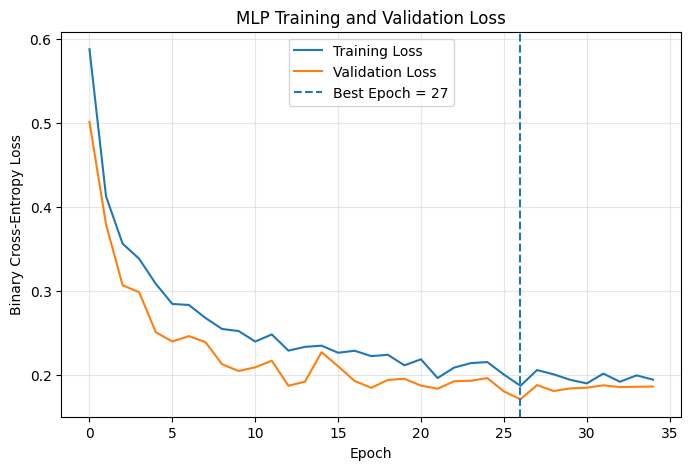

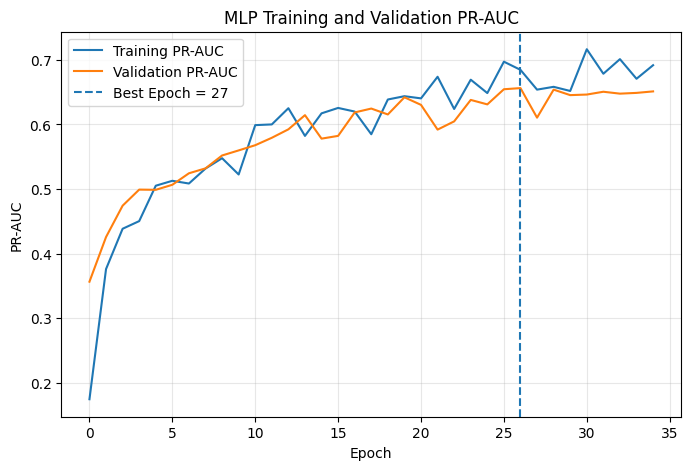

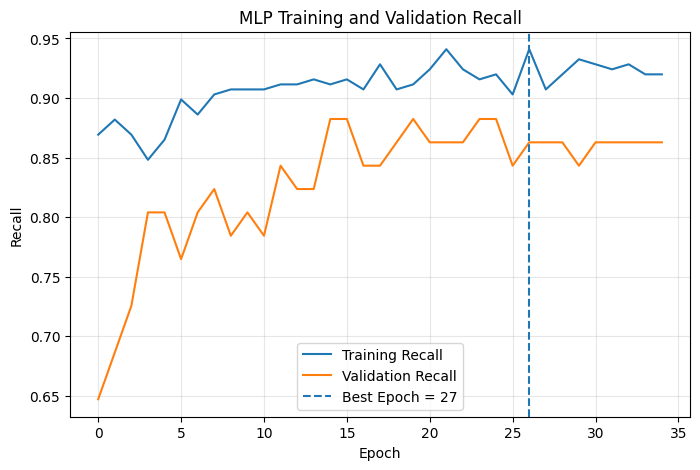

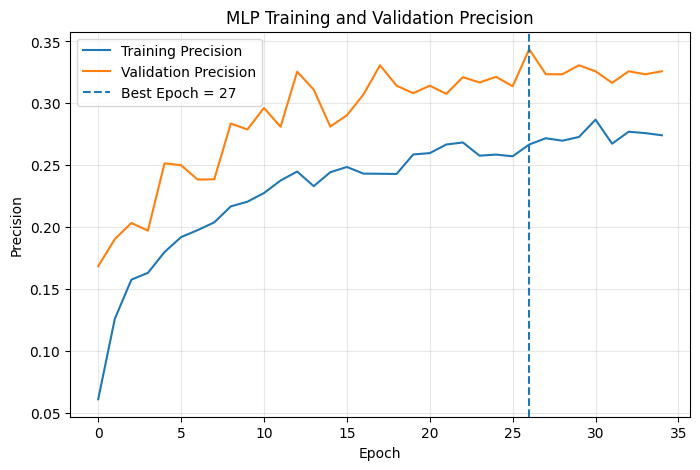

In [15]:
# ============================================================
# MLP TRAINING CURVES
# ============================================================

history_df = pd.DataFrame(
    mlp_history.history
)

best_epoch = int(
    history_df["val_pr_auc"].idxmax() + 1
)

best_val_pr_auc = history_df.loc[
    best_epoch - 1,
    "val_pr_auc"
]

best_val_recall = history_df.loc[
    best_epoch - 1,
    "val_recall"
]

best_val_precision = history_df.loc[
    best_epoch - 1,
    "val_precision"
]

best_val_loss = history_df.loc[
    best_epoch - 1,
    "val_loss"
]

print("Best epoch:", best_epoch)

print(
    f"Best validation PR-AUC: "
    f"{best_val_pr_auc:.4f}"
)

print(
    f"Validation recall at best epoch: "
    f"{best_val_recall:.4f}"
)

print(
    f"Validation precision at best epoch: "
    f"{best_val_precision:.4f}"
)

print(
    f"Validation loss at best epoch: "
    f"{best_val_loss:.4f}"
)


# Loss curve
plt.figure(figsize=(8, 5))

plt.plot(
    history_df["loss"],
    label="Training Loss"
)

plt.plot(
    history_df["val_loss"],
    label="Validation Loss"
)

plt.axvline(
    best_epoch - 1,
    linestyle="--",
    label=f"Best Epoch = {best_epoch}"
)

plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("MLP Training and Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# PR-AUC curve
plt.figure(figsize=(8, 5))

plt.plot(
    history_df["pr_auc"],
    label="Training PR-AUC"
)

plt.plot(
    history_df["val_pr_auc"],
    label="Validation PR-AUC"
)

plt.axvline(
    best_epoch - 1,
    linestyle="--",
    label=f"Best Epoch = {best_epoch}"
)

plt.xlabel("Epoch")
plt.ylabel("PR-AUC")
plt.title("MLP Training and Validation PR-AUC")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# Recall curve
plt.figure(figsize=(8, 5))

plt.plot(
    history_df["recall"],
    label="Training Recall"
)

plt.plot(
    history_df["val_recall"],
    label="Validation Recall"
)

plt.axvline(
    best_epoch - 1,
    linestyle="--",
    label=f"Best Epoch = {best_epoch}"
)

plt.xlabel("Epoch")
plt.ylabel("Recall")
plt.title("MLP Training and Validation Recall")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# Precision curve
plt.figure(figsize=(8, 5))

plt.plot(
    history_df["precision"],
    label="Training Precision"
)

plt.plot(
    history_df["val_precision"],
    label="Validation Precision"
)

plt.axvline(
    best_epoch - 1,
    linestyle="--",
    label=f"Best Epoch = {best_epoch}"
)

plt.xlabel("Epoch")
plt.ylabel("Precision")
plt.title("MLP Training and Validation Precision")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Training Curves — Observation

The training curves provide complementary evidence about the optimization behavior and generalization of the selected MLP.

Binary cross-entropy loss reflects the model's optimization progress, while PR-AUC provides the more operationally relevant view of minority-class discrimination under the highly imbalanced failure distribution.

The validation PR-AUC trajectory is particularly important because it determines the model checkpoint retained by Early Stopping. Rather than preserving the parameters from the final training epoch, the procedure restores the weights associated with the strongest observed validation PR-AUC.

The selected model reached its best validation PR-AUC at **Epoch 27**.

The curves are therefore used primarily as a training diagnostic and model-selection aid. The final assessment of predictive performance is performed separately on the untouched test set, ensuring that the training history does not substitute for independent generalization evaluation.

## 12. MLP Probability Predictions

The trained MLP produces a continuous machine-failure probability between 0 and 1 for each observation.

Probability predictions are generated separately for:

- The validation subset.
- The untouched test subset.

The validation probabilities will be used for subsequent decision-threshold analysis and cost-sensitive threshold optimization.

The test probabilities are generated for evaluation but are not used to select the classification threshold.

Maintaining this separation ensures that threshold-related decisions remain validation-based and prevents test-label information from influencing model selection.

In [16]:
# ============================================================
# GENERATE MLP PROBABILITIES
# ============================================================

mlp_val_proba = mlp_model.predict(
    X_val_scaled,
    verbose=0
).ravel()

mlp_test_proba = mlp_model.predict(
    X_test_scaled,
    verbose=0
).ravel()


print(
    "Validation probabilities shape:",
    mlp_val_proba.shape
)

print(
    "Test probabilities shape:",
    mlp_test_proba.shape
)


print(
    "\nValidation probability range:",
    f"{mlp_val_proba.min():.4f} - "
    f"{mlp_val_proba.max():.4f}"
)

print(
    "Test probability range:",
    f"{mlp_test_proba.min():.4f} - "
    f"{mlp_test_proba.max():.4f}"
)

Validation probabilities shape: (1500,)
Test probabilities shape: (1500,)

Validation probability range: 0.0001 - 1.0000
Test probability range: 0.0001 - 0.9997


### Observation

The trained MLP successfully generated probability estimates for all observations in both evaluation subsets:

- **Validation set:** 1,500 probability scores.
- **Test set:** 1,500 probability scores.

The predicted probability ranges are:

- **Validation:** approximately **0.0000 to 1.0000**
- **Test:** approximately **0.0000 to 0.9998**

The broad probability range indicates that the network produces strongly differentiated confidence scores rather than assigning nearly identical probabilities to most observations.

Some observations receive probabilities very close to zero, indicating strong confidence in the normal operating class, while others receive probabilities close to one, indicating strong predicted failure risk.

These continuous probability scores are suitable for the next evaluation stages because they support both threshold-independent metrics such as **PR-AUC and ROC-AUC** and validation-based cost-sensitive threshold optimization.

Importantly, the validation probabilities will be used to determine the operating threshold, while the test set remains reserved for evaluating the selected threshold.

## 13. MLP Evaluation at the Default Threshold

The standard classification threshold of **0.50** is first evaluated to establish a baseline for the trained MLP.

An observation is classified as a predicted machine failure when its estimated failure probability is greater than or equal to 0.50.

Because machine failures are rare, evaluation focuses on metrics that provide a more informative assessment than overall accuracy:

- **Precision** — proportion of predicted failures that are actual failures.
- **Recall** — proportion of actual failures correctly detected.
- **F1-score** — harmonic balance between precision and recall.
- **PR-AUC** — threshold-independent assessment of precision-recall ranking performance.
- **ROC-AUC** — threshold-independent ranking performance across sensitivity and specificity.
- **False-Negative Rate (FNR)** — proportion of actual failures that are missed.
- **Confusion-matrix counts** — true negatives, false positives, false negatives, and true positives.

The 0.50 threshold is used only as a reference point. A business-aware operating threshold will subsequently be selected using the validation subset.

In [17]:
# ============================================================
# MLP EVALUATION METRICS
# ============================================================

def get_mlp_metrics(y_true, y_pred, y_proba):

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    tn, fp, fn, tp = cm.ravel()

    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    pr_auc = average_precision_score(
        y_true,
        y_proba
    )

    roc_auc = roc_auc_score(
        y_true,
        y_proba
    )

    fnr = (
        fn / (fn + tp)
        if (fn + tp) > 0
        else 0.0
    )

    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "pr_auc": pr_auc,
        "roc_auc": roc_auc,
        "fnr": fnr,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp)
    }

In [18]:
# ============================================================
# DEFAULT THRESHOLD EVALUATION
# ============================================================

MLP_DEFAULT_THRESHOLD = 0.50

mlp_val_pred_default = (
    mlp_val_proba >= MLP_DEFAULT_THRESHOLD
).astype(int)

mlp_test_pred_default = (
    mlp_test_proba >= MLP_DEFAULT_THRESHOLD
).astype(int)


mlp_val_metrics_default = get_mlp_metrics(
    y_val,
    mlp_val_pred_default,
    mlp_val_proba
)

mlp_test_metrics_default = get_mlp_metrics(
    y_test,
    mlp_test_pred_default,
    mlp_test_proba
)


default_metrics_df = pd.DataFrame(
    [
        mlp_val_metrics_default,
        mlp_test_metrics_default
    ],
    index=[
        "Validation",
        "Test"
    ]
)

display(
    default_metrics_df[
        [
            "precision",
            "recall",
            "f1",
            "pr_auc",
            "roc_auc",
            "fnr",
            "tn",
            "fp",
            "fn",
            "tp"
        ]
    ].round(4)
)

,precision,recall,f1,pr_auc,roc_auc,fnr,tn,fp,fn,tp
Validation,0.3438,0.8627,0.4916,0.6635,0.9694,0.1373,1365,84,7,44
Test,0.3077,0.8627,0.4536,0.6618,0.9692,0.1373,1350,99,7,44


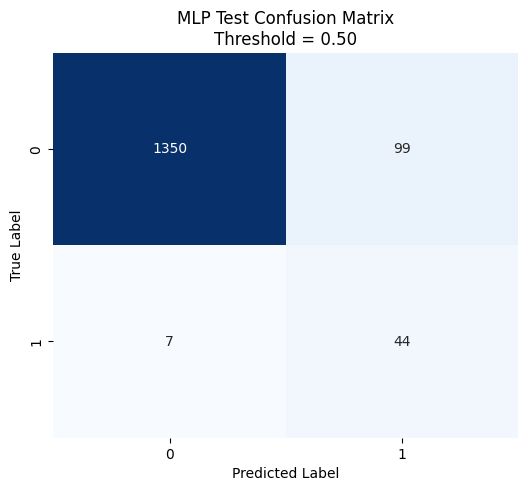

In [19]:
# ============================================================
# TEST CONFUSION MATRIX AT DEFAULT THRESHOLD
# ============================================================

mlp_test_cm_default = confusion_matrix(
    y_test,
    mlp_test_pred_default
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    mlp_test_cm_default,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.title(
    "MLP Test Confusion Matrix\n"
    "Threshold = 0.50"
)

plt.show()

### Default-Threshold Performance — Observation

Using the conventional classification threshold of **0.50**, the MLP demonstrates strong sensitivity to the minority machine-failure class on the untouched test set.

The model achieved:

| Metric | Test Performance |
|---|---:|
| Precision | **0.3077** |
| Recall | **0.8627** |
| F1-Score | **0.4536** |
| PR-AUC | **0.6618** |
| ROC-AUC | **0.9692** |
| False-Negative Rate | **0.1373** |
| True Negatives | **1,350** |
| False Positives | **99** |
| False Negatives | **7** |
| True Positives | **44** |

The MLP correctly identifies **44 of the 51 actual machine failures**, corresponding to a recall of approximately **86.3%**.

However, this failure sensitivity is accompanied by **99 false-positive maintenance alerts**, resulting in relatively low precision. The default threshold therefore demonstrates the expected trade-off between detecting rare failures and generating unnecessary maintenance interventions.

Under the established cost assumptions, this operating point produces an estimated test business cost of **84,500**.

These results establish the **0.50 threshold as the reference operating point** against which the validation-selected business-aware threshold is subsequently compared.

## 14. Cost-Sensitive MLP Threshold Optimization

The default threshold of 0.50 is not necessarily the most appropriate operating point for a predictive-maintenance system.

False negatives and false positives have different operational consequences:

- A **false negative** represents an actual machine failure that is missed.
- A **false positive** represents an unnecessary maintenance or inspection alert.

To preserve consistency with the previous business-evaluation stage, the same cost assumptions are used:

- **False Negative Cost (`C_FN`) = 5,000**
- **False Positive Cost (`C_FP`) = 500**

For each candidate classification threshold, estimated validation cost is calculated as:

**Total Cost = (FN × C_FN) + (FP × C_FP)**

The MLP threshold is optimized independently because probability distributions differ across models. Therefore, the operating threshold selected for the Classical Machine Learning model is not reused.

Threshold selection is performed exclusively on the **validation subset**. The test labels are not involved in this optimization process.

In [20]:
# ============================================================
# COST-SENSITIVE MLP THRESHOLD OPTIMIZATION
# ============================================================

C_FN = 5000
C_FP = 500

mlp_thresholds = np.linspace(
    0.01,
    0.99,
    99
)

mlp_validation_costs = []

for threshold in mlp_thresholds:

    mlp_val_pred_threshold = (
        mlp_val_proba >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_val,
        mlp_val_pred_threshold
    ).ravel()

    total_cost = (
        fn * C_FN
        + fp * C_FP
    )

    mlp_validation_costs.append(
        int(total_cost)
    )


best_threshold_index = int(
    np.argmin(
        mlp_validation_costs
    )
)

mlp_optimal_threshold = float(
    mlp_thresholds[
        best_threshold_index
    ]
)

mlp_min_validation_cost = int(
    mlp_validation_costs[
        best_threshold_index
    ]
)


print(
    f"Selected MLP threshold: "
    f"{mlp_optimal_threshold:.2f}"
)

print(
    f"Minimum validation cost: "
    f"{mlp_min_validation_cost:,}"
)

Selected MLP threshold: 0.36
Minimum validation cost: 75,500


## 15. Validation Cost Across Classification Thresholds

The estimated validation cost is examined across all candidate classification thresholds to visualize the business trade-off between missed failures and unnecessary maintenance alerts.

At lower thresholds, the MLP becomes more sensitive and classifies more observations as failures. This can reduce false negatives but may substantially increase false positives.

At higher thresholds, the classifier becomes more conservative. False-positive alerts may decrease, but actual failures may increasingly be missed.

Because the assigned cost of a false negative is substantially greater than the cost of a false positive, the selected threshold must balance these two error types according to their estimated operational impact.

The minimum point on the validation cost curve represents the selected operating threshold under the current cost assumptions.

The test set is not involved in this analysis.

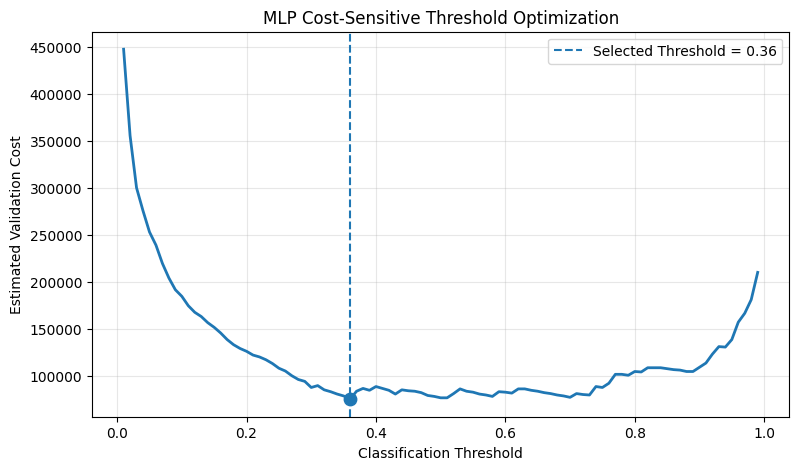

In [21]:
# ============================================================
# VALIDATION COST ACROSS THRESHOLDS
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    mlp_thresholds,
    mlp_validation_costs,
    linewidth=2
)

plt.axvline(
    mlp_optimal_threshold,
    linestyle="--",
    label=(
        f"Selected Threshold = "
        f"{mlp_optimal_threshold:.2f}"
    )
)

plt.scatter(
    mlp_optimal_threshold,
    mlp_min_validation_cost,
    s=80,
    zorder=3
)

plt.xlabel(
    "Classification Threshold"
)

plt.ylabel(
    "Estimated Validation Cost"
)

plt.title(
    "MLP Cost-Sensitive Threshold Optimization"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

## 16. Validation Performance Before and After Threshold Optimization

After selecting the business-aware MLP threshold exclusively from the validation subset, its operating behavior is compared with the conventional **0.50** decision threshold on the same validation data.

This comparison quantifies how the selected decision boundary changes failure sensitivity, false-negative exposure, unnecessary maintenance alerts, and estimated operational cost.

The evaluation considers:

- Precision, Recall, and F1-score.
- False-Negative Rate (FNR).
- True Negative, False Positive, False Negative, and True Positive counts.
- Estimated business cost under the established asymmetric cost assumptions.
- PR-AUC and ROC-AUC as threshold-independent discrimination metrics.

The default threshold serves as the reference operating point, while the selected threshold represents the validation-derived business-aware decision policy.

This comparison is performed **exclusively on the validation set**. The test set remains untouched until the selected threshold is locked and transferred to the independent test evaluation in the following section.

In [22]:
# ============================================================
# VALIDATION THRESHOLD COMPARISON
# ============================================================

mlp_val_pred_optimized = (
    mlp_val_proba >= mlp_optimal_threshold
).astype(int)


mlp_val_metrics_optimized = get_mlp_metrics(
    y_val,
    mlp_val_pred_optimized,
    mlp_val_proba
)


mlp_val_default_cost = int(
    mlp_val_metrics_default["fn"] * C_FN
    + mlp_val_metrics_default["fp"] * C_FP
)

mlp_val_optimized_cost = int(
    mlp_val_metrics_optimized["fn"] * C_FN
    + mlp_val_metrics_optimized["fp"] * C_FP
)


mlp_validation_comparison = pd.DataFrame(
    [
        {
            "threshold":
                MLP_DEFAULT_THRESHOLD,

            **mlp_val_metrics_default,

            "business_cost":
                mlp_val_default_cost
        },

        {
            "threshold":
                mlp_optimal_threshold,

            **mlp_val_metrics_optimized,

            "business_cost":
                mlp_val_optimized_cost
        }
    ],

    index=[
        "Default Threshold",
        "Optimized Threshold"
    ]
)


display(
    mlp_validation_comparison[
        [
            "threshold",
            "precision",
            "recall",
            "f1",
            "pr_auc",
            "roc_auc",
            "fnr",
            "tn",
            "fp",
            "fn",
            "tp",
            "business_cost"
        ]
    ].round(4)
)

,threshold,precision,recall,f1,pr_auc,roc_auc,fnr,tn,fp,fn,tp,business_cost
Default Threshold,0.50,0.3438,0.8627,0.4916,0.6635,0.9694,0.1373,1365,84,7,44,77000
Optimized Threshold,0.36,0.2722,0.9608,0.4242,0.6635,0.9694,0.0392,1318,131,2,49,75500


In [23]:
# ============================================================
# VALIDATION COST IMPROVEMENT
# ============================================================

mlp_val_cost_reduction = (
    mlp_val_default_cost
    - mlp_val_optimized_cost
)

mlp_val_cost_reduction_pct = (
    mlp_val_cost_reduction
    / mlp_val_default_cost
    * 100
    if mlp_val_default_cost > 0
    else 0.0
)

print(
    f"Default validation cost: "
    f"{mlp_val_default_cost:,}"
)

print(
    f"Optimized validation cost: "
    f"{mlp_val_optimized_cost:,}"
)

print(
    f"Validation cost reduction: "
    f"{mlp_val_cost_reduction:,}"
)

print(
    f"Validation cost reduction (%): "
    f"{mlp_val_cost_reduction_pct:.2f}%"
)

Default validation cost: 77,000
Optimized validation cost: 75,500
Validation cost reduction: 1,500
Validation cost reduction (%): 1.95%


### Validation Threshold Comparison — Observation

The validation comparison shows how the business-aware threshold changes the MLP operating behavior relative to the conventional **0.50** decision threshold.

The validation results are:

| Metric | Default Threshold (0.50) | Selected Threshold (0.36) |
|---|---:|---:|
| Precision | 0.3438 | 0.2722 |
| Recall | 0.8627 | **0.9608** |
| F1-Score | 0.4916 | 0.4242 |
| PR-AUC | 0.6635 | 0.6635 |
| ROC-AUC | 0.9694 | 0.9694 |
| False-Negative Rate | 0.1373 | **0.0392** |
| True Negatives | 1,365 | 1,318 |
| False Positives | 84 | 131 |
| False Negatives | 7 | **2** |
| True Positives | 44 | **49** |
| Business Cost | 77,000 | **75,500** |

Lowering the decision threshold from **0.50 to 0.36** substantially increases failure sensitivity on the validation set.

Recall improves from **0.8627 to 0.9608**, while the number of missed failures decreases from **7 to only 2**. Consequently, the False-Negative Rate falls from **0.1373 to 0.0392**.

This improvement is accompanied by an increase in false-positive maintenance alerts from **84 to 131**, reducing precision from **0.3438 to 0.2722**.

Under the established asymmetric cost assumptions, the estimated validation business cost decreases from **77,000 to 75,500**, corresponding to an absolute reduction of **1,500** or approximately **1.95%**.

PR-AUC and ROC-AUC remain unchanged because these are threshold-independent ranking metrics calculated from the same underlying probability scores.

Therefore, **0.36** is retained as the validation-selected business-aware MLP operating threshold and is locked before evaluation on the untouched test set.

## 17. MLP Evaluation Using the Optimized Threshold

After selecting the operating threshold exclusively from the validation subset, the threshold is locked and applied to the previously untouched test subset.

No test labels are used to select, adjust, or refine the threshold.

Performance at the optimized threshold is compared with the default 0.50 threshold to determine whether the business-aware decision rule generalizes to unseen observations.

The comparison evaluates:

- Precision.
- Recall.
- F1-score.
- PR-AUC.
- ROC-AUC.
- False-Negative Rate.
- Confusion-matrix counts.
- Estimated business cost.

This provides the operational test-set evaluation of the supervised MLP before comparison with the Autoencoder and Classical Machine Learning models.

In [24]:
# ============================================================
# APPLY OPTIMIZED THRESHOLD TO TEST SET
# ============================================================

mlp_test_pred_optimized = (
    mlp_test_proba >= mlp_optimal_threshold
).astype(int)


mlp_test_metrics_optimized = get_mlp_metrics(
    y_test,
    mlp_test_pred_optimized,
    mlp_test_proba
)


mlp_test_default_cost = int(
    mlp_test_metrics_default["fn"] * C_FN
    + mlp_test_metrics_default["fp"] * C_FP
)

mlp_test_optimized_cost = int(
    mlp_test_metrics_optimized["fn"] * C_FN
    + mlp_test_metrics_optimized["fp"] * C_FP
)

In [26]:
# ============================================================
# TEST BUSINESS COST COMPARISON
# ============================================================

mlp_test_cost_reduction = (
    mlp_test_default_cost
    - mlp_test_optimized_cost
)

mlp_test_cost_reduction_pct = (
    mlp_test_cost_reduction
    / mlp_test_default_cost
    * 100
    if mlp_test_default_cost > 0
    else 0.0
)


print(
    f"Selected threshold: "
    f"{mlp_optimal_threshold:.2f}"
)

print(
    f"Default test cost: "
    f"{mlp_test_default_cost:,}"
)

print(
    f"Optimized test cost: "
    f"{mlp_test_optimized_cost:,}"
)

print(
    f"Test cost reduction: "
    f"{mlp_test_cost_reduction:,}"
)

print(
    f"Test cost reduction (%): "
    f"{mlp_test_cost_reduction_pct:.2f}%"
)

Selected threshold: 0.36
Default test cost: 84,500
Optimized test cost: 99,500
Test cost reduction: -15,000
Test cost reduction (%): -17.75%


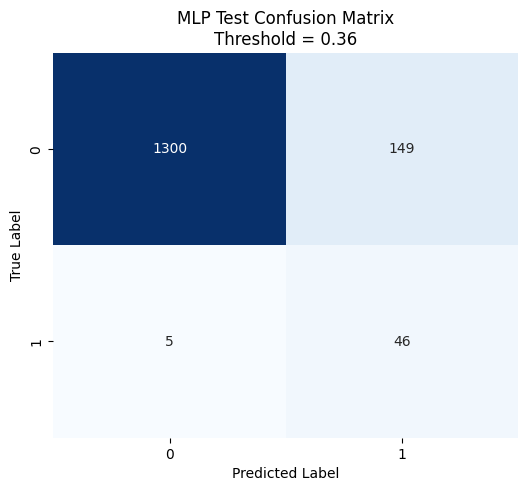

In [27]:
# ============================================================
# TEST CONFUSION MATRIX AT OPTIMIZED THRESHOLD
# ============================================================

mlp_test_cm_optimized = confusion_matrix(
    y_test,
    mlp_test_pred_optimized
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    mlp_test_cm_optimized,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.title(
    "MLP Test Confusion Matrix\n"
    f"Threshold = {mlp_optimal_threshold:.2f}"
)

plt.show()

### Optimized MLP — Test Insight

At the validation-selected threshold of **0.36**, the MLP achieved:

| Metric | Test Performance |
|---|---:|
| Precision | **0.2359** |
| Recall | **0.9020** |
| F1-Score | **0.3740** |
| PR-AUC | **0.6618** |
| ROC-AUC | **0.9692** |
| False-Negative Rate | **0.0980** |
| True Negatives | **1,300** |
| False Positives | **149** |
| False Negatives | **5** |
| True Positives | **46** |
| Business Cost | **99,500** |

The model detects **46 of the 51 actual machine failures**, making this operating point highly sensitive to failure events.

Compared with the default threshold, the selected threshold prevents **2 additional missed failures** but generates **50 additional false-positive maintenance alerts**.

The result demonstrates an important distinction between **validation optimization and test generalization**. Although 0.36 minimized the specified cost function on validation data, its test cost is higher than that of the default threshold.

The threshold nevertheless remains methodologically valid because it was selected without access to test labels. The observed test result therefore represents an unbiased evaluation of the validation-derived operating policy rather than a reason to retrospectively optimize against the test set.

## 18. Autoencoder for Unsupervised Anomaly Detection

The second Deep Learning component uses an **Autoencoder** to detect abnormal machine operating conditions without directly learning the `machine_failure` target.

Unlike the supervised MLP, the Autoencoder learns the structure of **normal machine behavior**.

The model is trained exclusively on healthy observations from the training partition (`machine_failure = 0`). During training, it learns to compress and reconstruct normal operating patterns.

The underlying anomaly-detection principle is:

> **Normal operating patterns → low reconstruction error**  
> **Abnormal operating patterns → potentially higher reconstruction error**

Because failure observations are excluded from Autoencoder training, the model is not explicitly taught what a failure looks like. This makes the approach suitable for detecting unusual operating conditions that deviate from the learned normal behavior.

The validation and test labels are retained only for later evaluation of anomaly-detection performance and are not used to train the Autoencoder.

## 19. Healthy-Only Autoencoder Training Data

Only normal observations from the existing training partition are selected for Autoencoder training.

The original train-validation-test split remains unchanged. No observations are transferred between subsets.

A healthy-only validation subset is also created from the existing validation partition. It is used to monitor reconstruction performance and control Autoencoder training without exposing the model to failure observations during optimization.

In [28]:
# ============================================================
# PREPARE HEALTHY-ONLY AUTOENCODER DATA
# ============================================================

X_train_healthy = X_train_scaled.loc[
    y_train == 0
].copy()

X_val_healthy = X_val_scaled.loc[
    y_val == 0
].copy()

print(
    "Total training observations:",
    X_train_scaled.shape[0]
)

print(
    "Healthy training observations:",
    X_train_healthy.shape[0]
)

print(
    "Failure observations excluded from AE training:",
    (y_train == 1).sum()
)

print(
    "\nTotal validation observations:",
    X_val_scaled.shape[0]
)

print(
    "Healthy validation observations:",
    X_val_healthy.shape[0]
)

print(
    "Failure observations excluded from AE validation:",
    (y_val == 1).sum()
)

print(
    "\nNumber of Autoencoder features:",
    X_train_healthy.shape[1]
)

Total training observations: 7000
Healthy training observations: 6763
Failure observations excluded from AE training: 237

Total validation observations: 1500
Healthy validation observations: 1449
Failure observations excluded from AE validation: 51

Number of Autoencoder features: 16


### Observation

The healthy-only Autoencoder training subset contains **6,763 normal observations** from the original 7,000 training samples.

A total of **237 failure observations** were excluded from Autoencoder training, ensuring that the model learns only the representation of normal machine operating conditions.

For validation, **1,449 healthy observations** are used to monitor reconstruction performance, while the **51 failure observations** remain excluded from the Autoencoder optimization process.

All observations retain the same **16 leakage-safe standardized features** used by the supervised MLP.

This separation preserves the unsupervised nature of the Autoencoder: failure labels are not used to learn the reconstruction function, and abnormal observations are not presented as examples of normal operating behavior during training.

## 20. Autoencoder Architecture

A compact fully connected Autoencoder is constructed to learn a compressed representation of normal machine operating conditions.

The network contains two main components:

- **Encoder:** progressively compresses the 16-dimensional input into a smaller latent representation.
- **Decoder:** reconstructs the original 16-dimensional feature vector from this compressed representation.

The architecture is:

**16 → 12 → 8 → 4 → 8 → 12 → 16**

The central **4-dimensional bottleneck** forces the network to retain the most important structure of normal operating behavior rather than simply copying the input.

ReLU activation is used in the hidden layers, while the output layer uses a **linear activation** because the standardized numerical features may contain both positive and negative values.

The Autoencoder is intentionally compact to reduce the risk of learning an identity mapping and to encourage meaningful compression of the normal operating patterns.

In [29]:
# ============================================================
# BUILD AUTOENCODER
# ============================================================
# Reset state before building the Autoencoder
keras.backend.clear_session()

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)


ae_input_dim = X_train_healthy.shape[1]

ae_inputs = keras.Input(
    shape=(ae_input_dim,),
    name="ae_input"
)

# Encoder
x = layers.Dense(
    12,
    activation="relu",
    name="encoder_dense_1"
)(ae_inputs)

x = layers.Dense(
    8,
    activation="relu",
    name="encoder_dense_2"
)(x)

latent = layers.Dense(
    4,
    activation="relu",
    name="latent_space"
)(x)

# Decoder
x = layers.Dense(
    8,
    activation="relu",
    name="decoder_dense_1"
)(latent)

x = layers.Dense(
    12,
    activation="relu",
    name="decoder_dense_2"
)(x)

ae_outputs = layers.Dense(
    ae_input_dim,
    activation="linear",
    name="reconstruction"
)(x)

autoencoder = keras.Model(
    inputs=ae_inputs,
    outputs=ae_outputs,
    name="normal_behavior_autoencoder"
)

autoencoder.summary()

Model: "normal_behavior_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ ae_input (InputLayer)           │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dense_1 (Dense)         │ (None, 12)             │           204 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dense_2 (Dense)         │ (None, 8)              │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_space (Dense)            │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dense_1 (Dense)         │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dense_2 (Dense)         │ (None, 12)             │           108 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstruction (Dense)          │ (None, 16)             │           208 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 700 (2.73 KB)

 Trainable params: 700 (2.73 KB)

 Non-trainable params: 0 (0.00 B)

## 21. Autoencoder Compilation

The Autoencoder is trained as a reconstruction model rather than a classifier.

The original healthy feature vector serves as both the input and the training target. The objective is therefore to minimize the difference between the original normal observation and its reconstructed representation.

**Mean Squared Error (MSE)** is used as the reconstruction loss:

**MSE = mean((X - X_reconstructed)²)**

Adam is used as the optimizer with an initial learning rate of 0.001.

Classification metrics such as precision and recall are not used during Autoencoder training because the model does not directly predict the failure label. These metrics will be calculated later after reconstruction errors are converted into anomaly decisions.

In [30]:
# ============================================================
# COMPILE AUTOENCODER
# ============================================================

autoencoder.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="mse"
)

print("Autoencoder compiled successfully.")

Autoencoder compiled successfully.


## 22. Autoencoder Training Strategy

The Autoencoder is trained exclusively on healthy training observations.

Healthy validation observations are used to monitor reconstruction performance during training. Failure observations are not supplied to the optimization process.

Two callbacks control the training procedure:

- **Early Stopping** terminates training when healthy validation reconstruction loss stops improving and restores the best model weights.
- **ReduceLROnPlateau** lowers the learning rate when validation reconstruction performance reaches a plateau.

Monitoring `val_loss` is appropriate because the objective of the Autoencoder is accurate reconstruction of normal operating patterns.

In [31]:
# ============================================================
# AUTOENCODER CALLBACKS
# ============================================================

ae_early_stopping = EarlyStopping(
    monitor="val_loss",
    mode="min",
    patience=8,
    restore_best_weights=True,
    verbose=1
)

ae_reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    mode="min",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

print("Autoencoder callbacks configured successfully.")

Autoencoder callbacks configured successfully.


## 23. Autoencoder Training

The Autoencoder is trained using only normal machine observations.

For each healthy observation, the same standardized feature vector is supplied as both the model input and reconstruction target.

A maximum of 100 epochs is allowed, while Early Stopping determines the effective training duration according to healthy validation reconstruction loss.

No failure labels or failure observations are used to update the Autoencoder parameters.

In [32]:
# ============================================================
# TRAIN AUTOENCODER ON HEALTHY MACHINES ONLY
# ============================================================

ae_history = autoencoder.fit(
    X_train_healthy,
    X_train_healthy,
    validation_data=(
        X_val_healthy,
        X_val_healthy
    ),
    epochs=100,
    batch_size=64,
    callbacks=[
        ae_early_stopping,
        ae_reduce_lr
    ],
    shuffle=True,
    verbose=1
)

Epoch 1/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.5755 - val_loss: 0.5216 - learning_rate: 0.0010
Epoch 2/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.4378 - val_loss: 0.3942 - learning_rate: 0.0010
Epoch 3/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.3338 - val_loss: 0.3108 - learning_rate: 0.0010
Epoch 4/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2680 - val_loss: 0.2463 - learning_rate: 0.0010
Epoch 5/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.2180 - val_loss: 0.2082 - learning_rate: 0.0010
Epoch 6/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1941 - val_loss: 0.1923 - learning_rate: 0.0010
Epoch 7/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1829 - val_loss: 0.1839 - learning_rate: 0.0010
Epoch 8/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1765 - val_loss: 0.1785 - learning_rate: 0.0010
Epoch 9/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1705 - val_loss: 0.1681 - learning_rate: 0.0010
E

## 24. Autoencoder Reconstruction-Loss Analysis

Training and validation reconstruction losses are compared across epochs to evaluate how effectively the Autoencoder learns normal machine behavior.

A decreasing training and validation loss indicates improving reconstruction capability.

A persistent divergence in which training loss continues decreasing while validation loss increases would suggest overfitting to the healthy training observations.

The best epoch is identified using the minimum healthy validation reconstruction loss.

Best Autoencoder epoch: 96
Best validation reconstruction loss: 0.096694


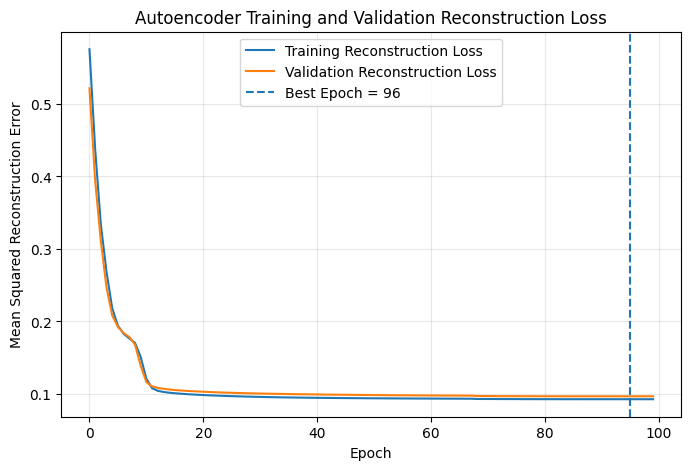

In [33]:
# ============================================================
# AUTOENCODER TRAINING CURVE
# ============================================================

ae_history_df = pd.DataFrame(
    ae_history.history
)

ae_best_epoch = int(
    np.argmin(ae_history_df["val_loss"]) + 1
)

ae_best_val_loss = float(
    ae_history_df["val_loss"].min()
)

print(
    "Best Autoencoder epoch:",
    ae_best_epoch
)

print(
    f"Best validation reconstruction loss: "
    f"{ae_best_val_loss:.6f}"
)

plt.figure(figsize=(8, 5))

plt.plot(
    ae_history_df["loss"],
    label="Training Reconstruction Loss"
)

plt.plot(
    ae_history_df["val_loss"],
    label="Validation Reconstruction Loss"
)

plt.axvline(
    ae_best_epoch - 1,
    linestyle="--",
    label=f"Best Epoch = {ae_best_epoch}"
)

plt.xlabel("Epoch")
plt.ylabel("Mean Squared Reconstruction Error")
plt.title(
    "Autoencoder Training and Validation Reconstruction Loss"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Autoencoder Training — Observation

The Autoencoder was trained exclusively on **healthy observations from the training partition**, enabling the network to learn a representation of normal machine operating behavior without using failure examples to define the reconstruction objective.

Training and healthy-validation reconstruction losses were monitored throughout optimization to assess convergence and generalization to unseen normal operating observations.

The final model retained the weights associated with the strongest healthy-validation reconstruction performance according to the configured training callbacks.

The close relationship between training and healthy-validation reconstruction behavior indicates that the model learned a transferable representation of normal operating patterns rather than simply memorizing the healthy training observations.

The resulting reconstruction model is therefore suitable for the next stage, where **mean squared reconstruction error** is used as a continuous anomaly score for both healthy and failure observations.

## 25. Reconstruction Error as an Anomaly Score

After training the Autoencoder on healthy machine observations, reconstruction error is used as a continuous anomaly score.

For each observation, the Autoencoder generates a reconstructed feature vector. The Mean Squared Error (MSE) between the original and reconstructed vectors is then calculated across all 16 input features.

A lower reconstruction error indicates that the observation closely resembles the normal operating patterns learned during training.

A higher reconstruction error indicates that the observation is more difficult for the Autoencoder to reconstruct and may therefore represent abnormal machine behavior.

Reconstruction errors are calculated for:

- Healthy training observations.
- All validation observations.
- All test observations.

At this stage, reconstruction error remains a continuous anomaly score. No anomaly threshold is selected yet.

In [34]:
# ============================================================
# COMPUTE AUTOENCODER RECONSTRUCTION ERRORS
# ============================================================

# Healthy training reconstructions
ae_train_reconstructed = autoencoder.predict(
    X_train_healthy,
    verbose=0
)

# Validation reconstructions
ae_val_reconstructed = autoencoder.predict(
    X_val_scaled,
    verbose=0
)

# Test reconstructions
ae_test_reconstructed = autoencoder.predict(
    X_test_scaled,
    verbose=0
)


# Mean Squared Reconstruction Error per observation
ae_train_error = np.mean(
    np.square(
        X_train_healthy.to_numpy()
        - ae_train_reconstructed
    ),
    axis=1
)

ae_val_error = np.mean(
    np.square(
        X_val_scaled.to_numpy()
        - ae_val_reconstructed
    ),
    axis=1
)

ae_test_error = np.mean(
    np.square(
        X_test_scaled.to_numpy()
        - ae_test_reconstructed
    ),
    axis=1
)


print("Reconstruction error arrays:")
print("Healthy Train:", ae_train_error.shape)
print("Validation:", ae_val_error.shape)
print("Test:", ae_test_error.shape)

print("\nHealthy training reconstruction error:")
print(f"Mean:   {ae_train_error.mean():.6f}")
print(f"Median: {np.median(ae_train_error):.6f}")
print(f"Min:    {ae_train_error.min():.6f}")
print(f"Max:    {ae_train_error.max():.6f}")

Reconstruction error arrays:
Healthy Train: (6763,)
Validation: (1500,)
Test: (1500,)

Healthy training reconstruction error:
Mean:   0.092647
Median: 0.078637
Min:    0.014888
Max:    0.450013


## 26. Reconstruction Error by Machine Status

To determine whether reconstruction error provides useful anomaly information, the validation anomaly scores are compared between healthy and failed machines.

The Autoencoder itself was trained without failure observations. Therefore, this comparison does not change the learned model parameters.

If machine failures correspond to operating patterns that differ from the learned normal behavior, failure observations should generally exhibit larger reconstruction errors than healthy observations.

The degree of separation between the two distributions determines how useful reconstruction error can be as an anomaly-detection signal.

In [35]:
# ============================================================
# HEALTHY VS FAILURE RECONSTRUCTION ERROR
# ============================================================

ae_val_error_normal = ae_val_error[
    y_val.to_numpy() == 0
]

ae_val_error_failure = ae_val_error[
    y_val.to_numpy() == 1
]

print("Validation Reconstruction Error Summary")
print("=" * 50)

print("\nHealthy Machines")
print(f"Count:  {len(ae_val_error_normal)}")
print(f"Mean:   {ae_val_error_normal.mean():.6f}")
print(f"Median: {np.median(ae_val_error_normal):.6f}")

print("\nFailed Machines")
print(f"Count:  {len(ae_val_error_failure)}")
print(f"Mean:   {ae_val_error_failure.mean():.6f}")
print(f"Median: {np.median(ae_val_error_failure):.6f}")

print(
    "\nMean Error Ratio (Failure / Healthy):",
    f"{ae_val_error_failure.mean() / ae_val_error_normal.mean():.2f}x"
)

Validation Reconstruction Error Summary

Healthy Machines
Count:  1449
Mean:   0.096694
Median: 0.080654

Failed Machines
Count:  51
Mean:   0.277346
Median: 0.101898

Mean Error Ratio (Failure / Healthy): 2.87x


## 27. Reconstruction Error Distribution

The reconstruction-error distributions of healthy and failed validation observations are visualized to assess their degree of separation.

A useful anomaly detector should assign systematically larger reconstruction errors to failed machines while maintaining relatively low errors for normal operating observations.

Some overlap is expected because not every machine failure necessarily produces an operating pattern that is strongly different from normal behavior.

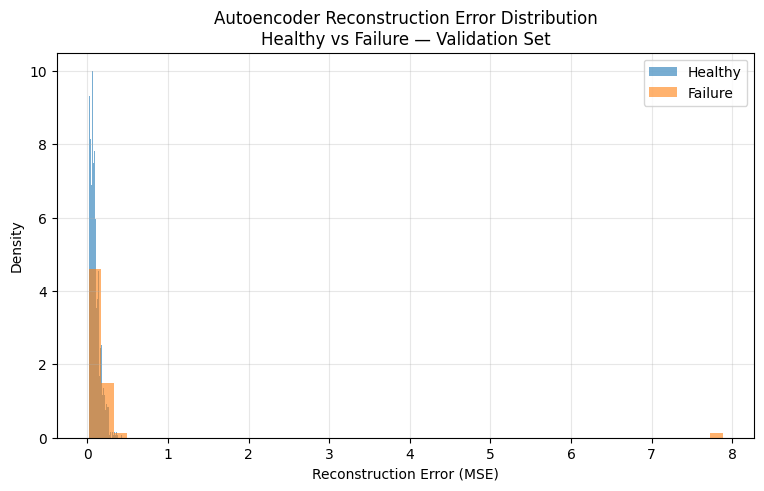

In [36]:
# ============================================================
# RECONSTRUCTION ERROR DISTRIBUTION
# ============================================================

plt.figure(figsize=(9, 5))

plt.hist(
    ae_val_error_normal,
    bins=50,
    alpha=0.6,
    density=True,
    label="Healthy"
)

plt.hist(
    ae_val_error_failure,
    bins=50,
    alpha=0.6,
    density=True,
    label="Failure"
)

plt.xlabel("Reconstruction Error (MSE)")
plt.ylabel("Density")

plt.title(
    "Autoencoder Reconstruction Error Distribution\n"
    "Healthy vs Failure — Validation Set"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

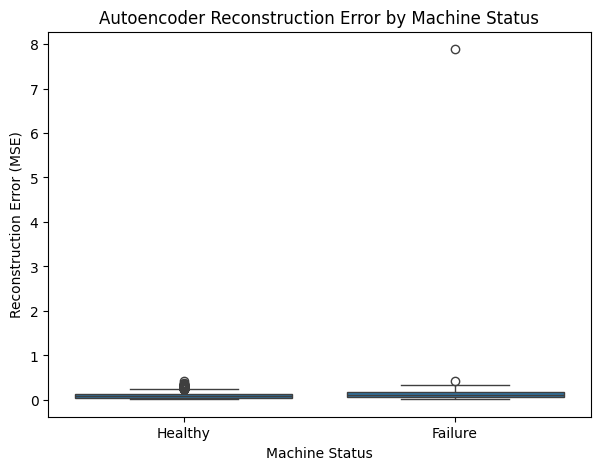

In [37]:
# ============================================================
# RECONSTRUCTION ERROR BOXPLOT
# ============================================================

ae_val_error_df = pd.DataFrame({
    "Reconstruction Error": ae_val_error,
    "Machine Status": np.where(
        y_val.to_numpy() == 1,
        "Failure",
        "Healthy"
    )
})

plt.figure(figsize=(7, 5))

sns.boxplot(
    data=ae_val_error_df,
    x="Machine Status",
    y="Reconstruction Error"
)

plt.xlabel("Machine Status")
plt.ylabel("Reconstruction Error (MSE)")
plt.title(
    "Autoencoder Reconstruction Error by Machine Status"
)

plt.show()

### Reconstruction Error Distribution — Observation

The reconstruction-error distributions show that the Autoencoder captures a measurable anomaly signal, but the separation between healthy and failed machines is not complete.

Failure observations tend to exhibit larger reconstruction errors when their operating conditions deviate from the healthy patterns learned during Autoencoder training. However, substantial overlap remains between the healthy and failure distributions.

This overlap is an important modeling result: **machine failure and unsupervised anomaly are related but not equivalent concepts**.

Some failure observations may remain relatively close to the learned healthy operating manifold, while unusual but healthy observations may produce comparatively large reconstruction errors.

Therefore, reconstruction error should be interpreted as a **continuous measure of abnormal operating behavior**, rather than as a direct supervised estimate of machine-failure probability.

This distinction supports using the Autoencoder as a complementary anomaly-detection component while retaining supervised models for direct failure-risk prediction.

## 28. Validation Discrimination of the Reconstruction Error

Before converting reconstruction error into a binary anomaly decision, its ability to distinguish failed from healthy machines is evaluated as a continuous anomaly score.

Two threshold-independent metrics are calculated:

- **PR-AUC:** measures how effectively reconstruction error identifies the rare failure class under strong class imbalance.
- **ROC-AUC:** measures the overall ranking ability of the anomaly score across healthy and failed observations.

No anomaly threshold is required for these metrics.

Because machine failures represent only a small proportion of the dataset, PR-AUC is particularly important for assessing whether the Autoencoder provides useful failure-related anomaly information.

In [38]:
# ============================================================
# AUTOENCODER VALIDATION ANOMALY-SCORE PERFORMANCE
# ============================================================

ae_val_pr_auc = average_precision_score(
    y_val,
    ae_val_error
)

ae_val_roc_auc = roc_auc_score(
    y_val,
    ae_val_error
)

print("Autoencoder Validation Anomaly-Score Performance")
print("=" * 55)

print(f"PR-AUC:  {ae_val_pr_auc:.4f}")
print(f"ROC-AUC: {ae_val_roc_auc:.4f}")

Autoencoder Validation Anomaly-Score Performance
PR-AUC:  0.0964
ROC-AUC: 0.6153


## 29. Unsupervised Anomaly Threshold Selection

A binary anomaly decision requires a reconstruction-error threshold above which an observation is classified as abnormal.

To preserve the unsupervised nature of the anomaly-detection pipeline, the threshold is derived exclusively from the reconstruction-error distribution of **healthy validation observations**.

The **95th percentile** of healthy validation reconstruction errors is selected as the operational anomaly threshold.

This approach does not use failure labels to optimize the threshold. Instead, it defines abnormal behavior relative to the reconstruction-error distribution observed under normal operating conditions.

Using a validation-based threshold also prevents information from the final test set from influencing anomaly-detector configuration.

The resulting threshold is subsequently frozen and applied once to the complete test set for final evaluation.

In [39]:
# ============================================================
# UNSUPERVISED AUTOENCODER ANOMALY THRESHOLD
# ============================================================

AE_THRESHOLD_PERCENTILE = 95

ae_anomaly_threshold = np.percentile(
    ae_val_error_normal,
    AE_THRESHOLD_PERCENTILE
)

print(
    f"Healthy validation percentile: "
    f"{AE_THRESHOLD_PERCENTILE}th"
)

print(
    f"Autoencoder anomaly threshold: "
    f"{ae_anomaly_threshold:.6f}"
)

healthy_val_flag_rate = np.mean(
    ae_val_error_normal > ae_anomaly_threshold
)

print(
    f"Healthy validation anomaly rate: "
    f"{healthy_val_flag_rate:.4%}"
)

Healthy validation percentile: 95th
Autoencoder anomaly threshold: 0.233644
Healthy validation anomaly rate: 5.0380%


## 30. Reconstruction Error with the Selected Anomaly Threshold

The selected threshold is visualized against the validation reconstruction-error distributions.

Observations with reconstruction errors above the threshold are classified as anomalies, while observations below the threshold remain within the learned normal operating region.

The visualization illustrates both the anomaly-detection boundary and the expected overlap between normal and failed machine behavior.

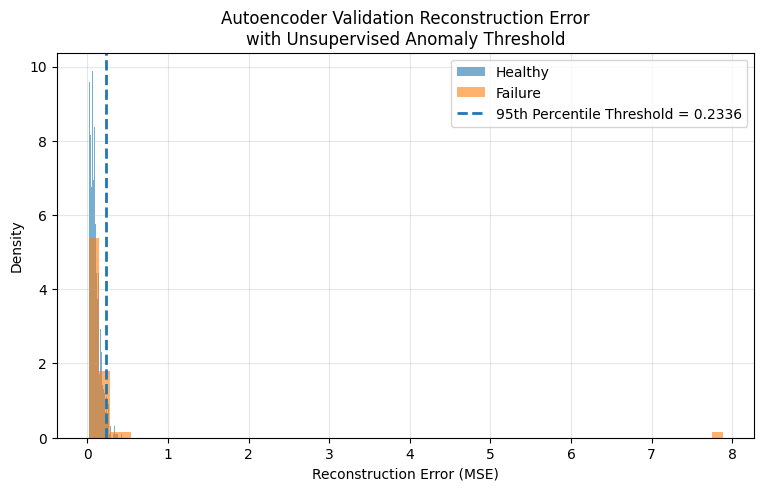

In [40]:
# ============================================================
# VISUALIZE AUTOENCODER ANOMALY THRESHOLD
# ============================================================

plt.figure(figsize=(9, 5))

plt.hist(
    ae_val_error_normal,
    bins=60,
    alpha=0.6,
    density=True,
    label="Healthy"
)

plt.hist(
    ae_val_error_failure,
    bins=60,
    alpha=0.6,
    density=True,
    label="Failure"
)

plt.axvline(
    ae_anomaly_threshold,
    linestyle="--",
    linewidth=2,
    label=(
        f"95th Percentile Threshold = "
        f"{ae_anomaly_threshold:.4f}"
    )
)

plt.xlabel("Reconstruction Error (MSE)")
plt.ylabel("Density")

plt.title(
    "Autoencoder Validation Reconstruction Error\n"
    "with Unsupervised Anomaly Threshold"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

## 31. Final Autoencoder Test Evaluation

After deriving the anomaly threshold exclusively from the reconstruction-error distribution of **healthy validation observations**, the threshold is locked before accessing test outcomes.

The selected anomaly threshold is approximately:

$$
\text{AE Threshold} = 0.233644
$$

This threshold corresponds to the **95th percentile of healthy validation reconstruction error** and is applied unchanged to the previously untouched test anomaly scores.

A test observation is classified as anomalous when:

$$
\text{Anomaly Prediction}
=
\begin{cases}
1, & \text{if Reconstruction Error} > 0.233644 \\
0, & \text{otherwise}
\end{cases}
$$

The resulting anomaly decisions are compared with the true `machine_failure` labels exclusively for independent evaluation.

The **continuous reconstruction error** is used to calculate PR-AUC and ROC-AUC, while the thresholded anomaly decisions are used to calculate Precision, Recall, F1-score, False-Negative Rate, and confusion-matrix outcomes.

No threshold adjustment is performed using test labels. This preserves the unsupervised threshold-selection procedure and provides an independent assessment of how well the learned anomaly criterion generalizes to unseen machine observations.

In [41]:
# ============================================================
# FINAL AUTOENCODER TEST EVALUATION
# ============================================================

ae_test_pred = (
    ae_test_error > ae_anomaly_threshold
).astype(int)

ae_test_cm = confusion_matrix(
    y_test,
    ae_test_pred
)

ae_tn, ae_fp, ae_fn, ae_tp = ae_test_cm.ravel()

ae_test_precision = precision_score(
    y_test,
    ae_test_pred,
    zero_division=0
)

ae_test_recall = recall_score(
    y_test,
    ae_test_pred,
    zero_division=0
)

ae_test_f1 = f1_score(
    y_test,
    ae_test_pred,
    zero_division=0
)

ae_test_pr_auc = average_precision_score(
    y_test,
    ae_test_error
)

ae_test_roc_auc = roc_auc_score(
    y_test,
    ae_test_error
)

ae_test_fnr = (
    ae_fn / (ae_fn + ae_tp)
    if (ae_fn + ae_tp) > 0
    else 0.0
)

ae_test_metrics = {
    "precision": ae_test_precision,
    "recall": ae_test_recall,
    "f1": ae_test_f1,
    "pr_auc": ae_test_pr_auc,
    "roc_auc": ae_test_roc_auc,
    "fnr": ae_test_fnr,
    "tn": ae_tn,
    "fp": ae_fp,
    "fn": ae_fn,
    "tp": ae_tp
}

print("Final Autoencoder Test Performance")
print("=" * 50)

for metric, value in ae_test_metrics.items():

    if metric in ["tn", "fp", "fn", "tp"]:
        print(f"{metric.upper():10s}: {value}")

    else:
        print(f"{metric.upper():10s}: {value:.4f}")

Final Autoencoder Test Performance
PRECISION : 0.0909
RECALL    : 0.0980
F1        : 0.0943
PR_AUC    : 0.1074
ROC_AUC   : 0.6603
FNR       : 0.9020
TN        : 1399
FP        : 50
FN        : 46
TP        : 5


## 32. Autoencoder Test Confusion Matrix

The confusion matrix provides an operational interpretation of the final unsupervised anomaly detector.

It shows how many actual machine failures are captured as anomalous, how many failures remain undetected, and how many healthy machines generate anomaly alerts.

This is particularly important in predictive maintenance because missed failures and unnecessary maintenance alerts have different operational consequences.

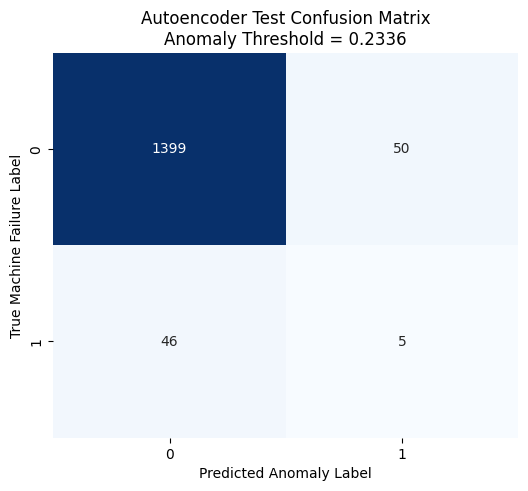

In [42]:
# ============================================================
# AUTOENCODER TEST CONFUSION MATRIX
# ============================================================

plt.figure(figsize=(6, 5))

sns.heatmap(
    ae_test_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False
)

plt.xlabel("Predicted Anomaly Label")
plt.ylabel("True Machine Failure Label")

plt.title(
    "Autoencoder Test Confusion Matrix\n"
    f"Anomaly Threshold = {ae_anomaly_threshold:.4f}"
)

plt.show()

## 33. Autoencoder Business-Cost Evaluation

For consistency with the supervised predictive-maintenance evaluation, the final Autoencoder anomaly decisions are also evaluated under the established business-cost assumptions:

- **False Negative Cost = 5000**
- **False Positive Cost = 500**

This calculation does not modify the anomaly threshold. The threshold remains the unsupervised 95th-percentile threshold selected previously.

The cost analysis is performed only to quantify the operational consequences of the final anomaly decisions and to support a fair comparison with the supervised MLP.

In [43]:
# ============================================================
# AUTOENCODER TEST BUSINESS COST
# ============================================================

ae_test_business_cost = (
    ae_fn * C_FN
    + ae_fp * C_FP
)

print(
    "Autoencoder Test Business Cost:",
    f"{ae_test_business_cost:,}"
)

print(
    "Missed Failure Cost:",
    f"{ae_fn * C_FN:,}"
)

print(
    "False Alert Cost:",
    f"{ae_fp * C_FP:,}"
)

Autoencoder Test Business Cost: 255,000
Missed Failure Cost: 230,000
False Alert Cost: 25,000


### Autoencoder Business-Cost Evaluation — Insight

Using the anomaly threshold derived exclusively from healthy validation reconstruction errors, the Autoencoder achieved the following performance on the untouched test set:

| Metric | Test Performance |
|---|---:|
| Anomaly Threshold | **0.2336** |
| Precision | **0.0909** |
| Recall | **0.0980** |
| F1-Score | **0.0943** |
| PR-AUC | **0.1074** |
| ROC-AUC | **0.6603** |
| False-Negative Rate | **0.9020** |
| True Negatives | **1,399** |
| False Positives | **50** |
| False Negatives | **46** |
| True Positives | **5** |
| Business Cost | **255,000** |

The Autoencoder detects only **5 of the 51 actual machine failures**, while **46 failures remain undetected**.

Under the established business-cost assumptions, missed failures dominate the total operational cost:

$$
(46 \times 5{,}000)
+
(50 \times 500)
=
255{,}000
$$

The result demonstrates that reconstruction-based anomaly detection is not sufficiently sensitive to operate as the primary machine-failure decision model on this dataset.

The Autoencoder should therefore be retained as a **complementary unsupervised monitoring component**, where its reconstruction-error score provides information about deviation from learned healthy operating behavior rather than serving as a direct replacement for supervised failure prediction.

## 34. Supervised MLP vs Unsupervised Autoencoder

The supervised MLP and unsupervised Autoencoder are compared using the same untouched test partition.

The two models represent fundamentally different approaches:

- **Optimized MLP:** supervised machine-failure prediction using the known `machine_failure` target and a validation-selected cost-sensitive threshold.
- **Autoencoder:** unsupervised anomaly detection trained exclusively on healthy observations, with its anomaly threshold derived from the healthy validation reconstruction-error distribution.

The comparison uses the same test observations and evaluates Precision, Recall, F1-score, PR-AUC, ROC-AUC, False-Negative Rate, confusion-matrix counts, and estimated business cost.

This comparison determines the appropriate operational role of each Deep Learning approach within the predictive-maintenance system.

In [44]:
# ============================================================
# MLP VS AUTOENCODER TEST COMPARISON
# ============================================================

mlp_test_precision_opt = (
    mlp_test_metrics_optimized["precision"]
)

mlp_test_recall_opt = (
    mlp_test_metrics_optimized["recall"]
)

mlp_test_f1_opt = (
    mlp_test_metrics_optimized["f1"]
)

mlp_test_pr_auc = (
    mlp_test_metrics_optimized["pr_auc"]
)

mlp_test_roc_auc = (
    mlp_test_metrics_optimized["roc_auc"]
)

mlp_test_fnr_opt = (
    mlp_test_metrics_optimized["fnr"]
)

mlp_tn = (
    mlp_test_metrics_optimized["tn"]
)

mlp_fp = (
    mlp_test_metrics_optimized["fp"]
)

mlp_fn = (
    mlp_test_metrics_optimized["fn"]
)

mlp_tp = (
    mlp_test_metrics_optimized["tp"]
)

mlp_test_business_cost = (
    mlp_test_optimized_cost
)


dl_comparison = pd.DataFrame(
    {
        "Optimized MLP": {
            "Threshold": mlp_optimal_threshold,
            "Precision": mlp_test_precision_opt,
            "Recall": mlp_test_recall_opt,
            "F1": mlp_test_f1_opt,
            "PR-AUC": mlp_test_pr_auc,
            "ROC-AUC": mlp_test_roc_auc,
            "FNR": mlp_test_fnr_opt,
            "TN": mlp_tn,
            "FP": mlp_fp,
            "FN": mlp_fn,
            "TP": mlp_tp,
            "Business Cost": mlp_test_business_cost
        },

        "Autoencoder": {
            "Threshold": ae_anomaly_threshold,
            "Precision": ae_test_precision,
            "Recall": ae_test_recall,
            "F1": ae_test_f1,
            "PR-AUC": ae_test_pr_auc,
            "ROC-AUC": ae_test_roc_auc,
            "FNR": ae_test_fnr,
            "TN": ae_tn,
            "FP": ae_fp,
            "FN": ae_fn,
            "TP": ae_tp,
            "Business Cost": ae_test_business_cost
        }
    }
)


print(
    f"MLP optimized threshold: "
    f"{mlp_optimal_threshold:.2f}"
)

print(
    f"Autoencoder anomaly threshold: "
    f"{ae_anomaly_threshold:.6f}"
)

print(
    "\nDeep Learning Test Comparison:"
)

display(
    dl_comparison.round(4)
)

MLP optimized threshold: 0.36
Autoencoder anomaly threshold: 0.233644

Deep Learning Test Comparison:


,Optimized MLP,Autoencoder
Threshold,0.3600,0.2336
Precision,0.2359,0.0909
Recall,0.9020,0.0980
F1,0.3740,0.0943
PR-AUC,0.6618,0.1074
ROC-AUC,0.9692,0.6603
FNR,0.0980,0.9020
TN,1300.0000,1399.0000
FP,149.0000,50.0000
FN,5.0000,46.0000


### Deep Learning Comparison — Insight

The test-set comparison demonstrates a clear performance advantage for the **supervised MLP** over the **unsupervised Autoencoder** when the objective is direct machine-failure detection.

At its validation-selected threshold of **0.36**, the MLP detects **46 of the 51 actual failures**, achieving:

- **Recall:** 0.9020
- **F1-Score:** 0.3740
- **PR-AUC:** 0.6618
- **ROC-AUC:** 0.9692
- **False-Negative Rate:** 0.0980

In contrast, the Autoencoder detects only **5 of the 51 failures**, with:

- **Recall:** 0.0980
- **F1-Score:** 0.0943
- **PR-AUC:** 0.1074
- **ROC-AUC:** 0.6603
- **False-Negative Rate:** 0.9020

The difference reflects the distinct learning objectives of the two models. The MLP learns discriminative patterns directly from labeled failure observations, whereas the Autoencoder learns only the structure of healthy operating behavior.

Accordingly, the two outputs should not be treated as interchangeable predictions:

- **MLP probability → supervised failure-risk signal**
- **Autoencoder reconstruction error → unsupervised anomaly signal**

The MLP is therefore the stronger Deep Learning model for direct failure prediction, while the Autoencoder provides a complementary view of abnormal machine behavior.

## 35. Deep Learning Business-Cost Comparison

Because missed machine failures are substantially more expensive than unnecessary maintenance alerts, the two Deep Learning approaches are also compared from an operational cost perspective.

The same business-cost assumptions used throughout the predictive-maintenance pipeline are applied consistently:

- **False Negative Cost = 5,000**
- **False Positive Cost = 500**

The estimated test business cost is calculated as:

$$
\text{Business Cost}
=
(\text{FN} \times 5{,}000)
+
(\text{FP} \times 500)
$$

The comparison uses the locked test-set decisions generated by:

- The **MLP** at its validation-selected business-aware threshold of **0.36**.
- The **Autoencoder** at its healthy-validation-derived anomaly threshold of approximately **0.233644**.

Neither threshold is modified using test-set information.

This provides a consistent operational comparison of the two Deep Learning approaches while preserving the distinction between supervised failure prediction and unsupervised anomaly detection.

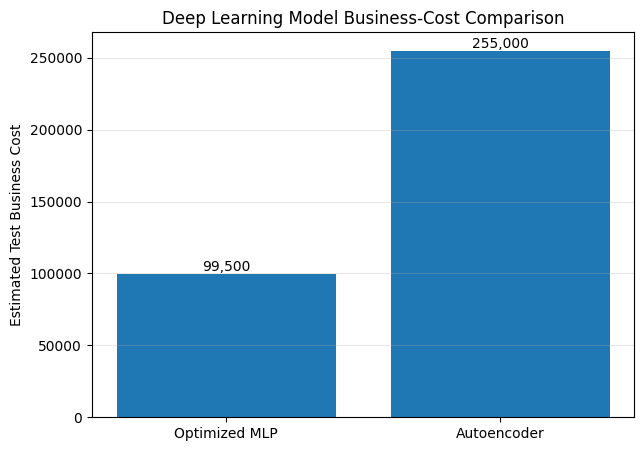

In [45]:
# ============================================================
# DEEP LEARNING BUSINESS-COST COMPARISON
# ============================================================

model_names = [
    "Optimized MLP",
    "Autoencoder"
]

business_costs = [
    mlp_test_business_cost,
    ae_test_business_cost
]

plt.figure(figsize=(7, 5))

bars = plt.bar(
    model_names,
    business_costs
)

plt.ylabel("Estimated Test Business Cost")
plt.title(
    "Deep Learning Model Business-Cost Comparison"
)

for bar, cost in zip(bars, business_costs):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{cost:,.0f}",
        ha="center",
        va="bottom"
    )

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

### Deep Learning Business-Cost Comparison — Insight

The business-cost comparison further demonstrates the operational difference between supervised failure prediction and unsupervised anomaly detection.

Under the common project assumptions:

\[
C_{FN}=5000,\qquad C_{FP}=500
\]

the test-set outcomes are:

| Model | False Positives | False Negatives | Business Cost |
|---|---:|---:|---:|
| **MLP** | 149 | **5** | **99,500** |
| **Autoencoder** | 50 | 46 | **255,000** |

Although the MLP generates more false-positive maintenance alerts, it misses dramatically fewer actual failures.

Because each missed failure carries ten times the assumed cost of a false alert, the reduction from **46 Autoencoder false negatives to only 5 MLP false negatives** produces a substantially lower overall business cost.

The MLP therefore reduces estimated business cost by **155,500**, corresponding to approximately **61.0%** relative to the Autoencoder.

Consequently, the MLP is the preferred Deep Learning component for direct failure-risk prediction, while the Autoencoder remains better suited to complementary anomaly monitoring.

## 36. Save Deep Learning Models and Integration Artifacts

The trained Deep Learning models and their associated decision configurations are saved to support reproducibility, deployment, monitoring, and downstream system integration.

The exported artifacts preserve the complete Deep Learning stage without requiring the models to be retrained before use by later project components.

The saved outputs include:

- The trained **MLP failure-prediction model** using the selected Deep Learning configuration.
- The trained **Autoencoder anomaly-detection model** learned from healthy machine observations.
- The validation-selected **MLP operating threshold**.
- The healthy-validation-derived **Autoencoder anomaly threshold**.
- Test-set performance metrics for both Deep Learning approaches.
- Test-level MLP failure probabilities and predictions.
- Test-level Autoencoder reconstruction-error scores and anomaly predictions.
- The supervised MLP versus unsupervised Autoencoder comparison results.

The MLP and Autoencoder models are stored separately from their operating thresholds because the neural-network parameters represent learned model behavior, whereas the thresholds represent decision-policy configuration selected after training.

The preprocessing scaler is not refitted or duplicated in this stage. Both Deep Learning models remain aligned with the leakage-safe preprocessing pipeline established upstream.

In [46]:
# ============================================================
# DEEP LEARNING ARTIFACT DIRECTORIES
# ============================================================

import os
import json

BASE_DIR = "/content"

MODELS_DIR = os.path.join(
    BASE_DIR,
    "models"
)

FIGURES_DIR = os.path.join(
    BASE_DIR,
    "figures"
)

os.makedirs(
    MODELS_DIR,
    exist_ok=True
)

os.makedirs(
    FIGURES_DIR,
    exist_ok=True
)

print("Models directory:", MODELS_DIR)
print("Figures directory:", FIGURES_DIR)

Models directory: /content/models
Figures directory: /content/figures


## 37. Export Trained Neural Models

Both trained neural networks are exported using the native Keras model format for reproducibility and downstream deployment.

The saved **MLP** preserves the supervised failure-prediction network trained using the selected hyperparameter configuration.

The saved **Autoencoder** preserves the reconstruction model trained exclusively on healthy machine observations.

Saving the complete Keras models preserves their architectures and learned weights, allowing downstream components to load them directly without repeating model construction or training.

In [47]:
# ============================================================
# EXPORT TRAINED NEURAL MODELS
# ============================================================

MLP_MODEL_PATH = os.path.join(
    MODELS_DIR,
    "mlp_failure_classifier.keras"
)

AUTOENCODER_MODEL_PATH = os.path.join(
    MODELS_DIR,
    "autoencoder_anomaly_detector.keras"
)


mlp_model.save(
    MLP_MODEL_PATH
)

autoencoder.save(
    AUTOENCODER_MODEL_PATH
)


print(
    "MLP model saved to:",
    MLP_MODEL_PATH
)

print(
    "Autoencoder model saved to:",
    AUTOENCODER_MODEL_PATH
)

MLP model saved to: /content/models/mlp_failure_classifier.keras
Autoencoder model saved to: /content/models/autoencoder_anomaly_detector.keras


## 38. Export Deep Learning Decision Thresholds

The operating thresholds for the two Deep Learning approaches are exported separately from the trained model files because they represent **decision-policy configuration** rather than learned neural-network parameters.

Each model uses an independent threshold-selection strategy appropriate to its modeling objective:

- **MLP threshold:** selected exclusively on the validation set through cost-sensitive optimization using the predefined false-negative and false-positive costs.
- **Autoencoder threshold:** derived from the **95th percentile of healthy validation reconstruction errors**, preserving the unsupervised anomaly-detection strategy.

The test set is not used to select or modify either threshold.

Saving these thresholds explicitly ensures that downstream inference, deployment, and monitoring components reproduce the same decision rules used during model evaluation.

In [48]:
# ============================================================
# SAVE DEEP LEARNING DECISION THRESHOLDS
# ============================================================

dl_thresholds = {
    "mlp": {
        "threshold": float(
            mlp_optimal_threshold
        ),
        "selection_method":
            "validation_cost_optimization",
        "false_negative_cost": int(
            C_FN
        ),
        "false_positive_cost": int(
            C_FP
        )
    },

    "autoencoder": {
        "threshold": float(
            ae_anomaly_threshold
        ),
        "selection_method":
            "95th_percentile_healthy_validation_error",
        "percentile": int(
            AE_THRESHOLD_PERCENTILE
        ),
        "score":
            "mean_squared_reconstruction_error"
    }
}


DL_THRESHOLDS_PATH = os.path.join(
    MODELS_DIR,
    "deep_learning_thresholds.json"
)


with open(
    DL_THRESHOLDS_PATH,
    "w"
) as file:

    json.dump(
        dl_thresholds,
        file,
        indent=4
    )


print(
    json.dumps(
        dl_thresholds,
        indent=4
    )
)

print(
    "\nThreshold configuration saved to:",
    DL_THRESHOLDS_PATH
)

{
    "mlp": {
        "threshold": 0.36000000000000004,
        "selection_method": "validation_cost_optimization",
        "false_negative_cost": 5000,
        "false_positive_cost": 500
    },
    "autoencoder": {
        "threshold": 0.23364410751787207,
        "selection_method": "95th_percentile_healthy_validation_error",
        "percentile": 95,
        "score": "mean_squared_reconstruction_error"
    }
}

Threshold configuration saved to: /content/models/deep_learning_thresholds.json


## 39. Export Deep Learning Metrics

The evaluated test-set performance of both Deep Learning approaches is exported as a structured JSON artifact for reproducibility, downstream model comparison, deployment, and monitoring.

The exported metrics preserve the locked test performance of:

- **Optimized MLP:** supervised machine-failure prediction using the validation-selected cost-sensitive threshold.
- **Autoencoder:** unsupervised anomaly detection using the healthy-validation-derived reconstruction-error threshold.

For each approach, the artifact stores:

- Decision threshold
- Precision
- Recall
- F1-score
- PR-AUC
- ROC-AUC
- False-Negative Rate (FNR)
- Confusion-matrix counts
- Estimated business cost

The exported values are derived from the already evaluated test predictions. No model retraining, threshold optimization, or test-set tuning is performed during this export stage.

In [49]:
# ============================================================
# SAVE DEEP LEARNING METRICS
# ============================================================

dl_metrics = {
    "optimized_mlp": {
        "threshold":
            float(mlp_optimal_threshold),

        "precision":
            float(mlp_test_metrics_optimized["precision"]),

        "recall":
            float(mlp_test_metrics_optimized["recall"]),

        "f1":
            float(mlp_test_metrics_optimized["f1"]),

        "pr_auc":
            float(mlp_test_metrics_optimized["pr_auc"]),

        "roc_auc":
            float(mlp_test_metrics_optimized["roc_auc"]),

        "fnr":
            float(mlp_test_metrics_optimized["fnr"]),

        "tn":
            int(mlp_test_metrics_optimized["tn"]),

        "fp":
            int(mlp_test_metrics_optimized["fp"]),

        "fn":
            int(mlp_test_metrics_optimized["fn"]),

        "tp":
            int(mlp_test_metrics_optimized["tp"]),

        "business_cost":
            int(mlp_test_optimized_cost)
    },

    "autoencoder": {
        "threshold":
            float(ae_anomaly_threshold),

        "precision":
            float(ae_test_precision),

        "recall":
            float(ae_test_recall),

        "f1":
            float(ae_test_f1),

        "pr_auc":
            float(ae_test_pr_auc),

        "roc_auc":
            float(ae_test_roc_auc),

        "fnr":
            float(ae_test_fnr),

        "tn":
            int(ae_tn),

        "fp":
            int(ae_fp),

        "fn":
            int(ae_fn),

        "tp":
            int(ae_tp),

        "business_cost":
            int(ae_test_business_cost)
    }
}


DL_METRICS_PATH = os.path.join(
    MODELS_DIR,
    "deep_learning_metrics.json"
)


with open(
    DL_METRICS_PATH,
    "w"
) as file:

    json.dump(
        dl_metrics,
        file,
        indent=4
    )


print(
    json.dumps(
        dl_metrics,
        indent=4
    )
)

print(
    "\nDeep Learning metrics saved to:",
    DL_METRICS_PATH
)

{
    "optimized_mlp": {
        "threshold": 0.36000000000000004,
        "precision": 0.2358974358974359,
        "recall": 0.9019607843137255,
        "f1": 0.37398373983739835,
        "pr_auc": 0.6618312803062504,
        "roc_auc": 0.9692147390357109,
        "fnr": 0.09803921568627451,
        "tn": 1300,
        "fp": 149,
        "fn": 5,
        "tp": 46,
        "business_cost": 99500
    },
    "autoencoder": {
        "threshold": 0.23364410751787207,
        "precision": 0.09090909090909091,
        "recall": 0.09803921568627451,
        "f1": 0.09433962264150944,
        "pr_auc": 0.10739551022597515,
        "roc_auc": 0.6603066347311872,
        "fnr": 0.9019607843137255,
        "tn": 1399,
        "fp": 50,
        "fn": 46,
        "tp": 5,
        "business_cost": 255000
    }
}

Deep Learning metrics saved to: /content/models/deep_learning_metrics.json


## 40. Export Deep Learning Model Comparison

The test-set comparison between the **optimized MLP** and the **Autoencoder** is exported as a CSV artifact to support downstream reporting, deployment, monitoring, and model integration.

The exported comparison summarizes the predictive and operational performance of both Deep Learning approaches using the same untouched test partition.

The artifact includes:

- Decision threshold
- Precision
- Recall
- F1-score
- PR-AUC
- ROC-AUC
- False-Negative Rate (FNR)
- Confusion-matrix counts
- Estimated business cost

The comparison table is generated from the already evaluated models and locked decision thresholds. No additional model fitting or threshold optimization is performed during this export stage.

In [50]:
# ============================================================
# SAVE DEEP LEARNING MODEL COMPARISON
# ============================================================

DL_COMPARISON_PATH = os.path.join(
    MODELS_DIR,
    "deep_learning_model_comparison.csv"
)


dl_comparison.to_csv(
    DL_COMPARISON_PATH
)


print(
    "Deep Learning comparison saved to:",
    DL_COMPARISON_PATH
)


print(
    "\nExported Deep Learning Comparison:"
)


display(
    dl_comparison.round(4)
)

Deep Learning comparison saved to: /content/models/deep_learning_model_comparison.csv

Exported Deep Learning Comparison:


,Optimized MLP,Autoencoder
Threshold,0.3600,0.2336
Precision,0.2359,0.0909
Recall,0.9020,0.0980
F1,0.3740,0.0943
PR-AUC,0.6618,0.1074
ROC-AUC,0.9692,0.6603
FNR,0.0980,0.9020
TN,1300.0000,1399.0000
FP,149.0000,50.0000
FN,5.0000,46.0000


## 41. Export Test-Level Deep Learning Outputs

Test-level outputs from both Deep Learning approaches are exported to support downstream monitoring, deployment, error analysis, model integration, and per-observation comparison.

For every observation in the untouched test partition, the exported artifact preserves:

- The true `machine_failure` label.
- The MLP predicted failure probability.
- The MLP binary prediction using the validation-selected threshold.
- The Autoencoder reconstruction-error anomaly score.
- The Autoencoder binary anomaly prediction using the healthy-validation-derived threshold.

The original test-set row index is retained to preserve alignment with upstream data and downstream integration components.

These outputs are generated from the already evaluated models and locked decision thresholds. No additional model fitting or threshold selection is performed in this export stage.

In [51]:
# ============================================================
# SAVE TEST-LEVEL DEEP LEARNING OUTPUTS
# ============================================================

dl_test_outputs = pd.DataFrame(
    {
        "machine_failure":
            y_test.to_numpy(),

        "mlp_failure_probability":
            mlp_test_proba,

        "mlp_prediction":
            mlp_test_pred_optimized,

        "autoencoder_anomaly_score":
            ae_test_error,

        "autoencoder_anomaly_prediction":
            ae_test_pred
    },
    index=y_test.index
)


dl_test_outputs.index.name = (
    "original_row_index"
)


DL_TEST_OUTPUTS_PATH = os.path.join(
    MODELS_DIR,
    "deep_learning_test_outputs.csv"
)


dl_test_outputs.to_csv(
    DL_TEST_OUTPUTS_PATH
)


print(
    "Test-level Deep Learning outputs saved to:",
    DL_TEST_OUTPUTS_PATH
)

print(
    "\nOutput shape:",
    dl_test_outputs.shape
)

print(
    "\nColumns:"
)

print(
    dl_test_outputs.columns.tolist()
)


dl_test_outputs.head()

Test-level Deep Learning outputs saved to: /content/models/deep_learning_test_outputs.csv

Output shape: (1500, 5)

Columns:
['machine_failure', 'mlp_failure_probability', 'mlp_prediction', 'autoencoder_anomaly_score', 'autoencoder_anomaly_prediction']


,machine_failure,mlp_failure_probability,mlp_prediction,autoencoder_anomaly_score,autoencoder_anomaly_prediction
original_row_index,,,,,
1529,0,0.003595,0,0.027736,0
8572,0,0.006521,0,0.060339,0
4330,0,0.009962,0,0.161556,0
1502,0,0.334738,0,0.026716,0
9355,0,0.001203,0,0.020531,0


## 42. Deep Learning Artifact Verification

Before completing the Deep Learning stage, all required exported artifacts are verified to confirm that the models, decision thresholds, evaluation metrics, comparison results, and test-level integration outputs were successfully created.

This verification checks the availability of:

- The trained MLP failure-prediction model.
- The trained Autoencoder anomaly-detection model.
- The Deep Learning decision-threshold configuration.
- The Deep Learning evaluation-metrics artifact.
- The MLP-versus-Autoencoder comparison artifact.
- The test-level Deep Learning outputs.

Verifying these dependencies before downstream integration reduces the risk of missing artifacts during deployment, monitoring, or cross-model evaluation.

This stage verifies artifact availability only; it does not retrain models, recompute predictions, or modify previously selected decision thresholds.

In [52]:
# ============================================================
# VERIFY EXPORTED DEEP LEARNING ARTIFACTS
# ============================================================

# Define required artifact paths
MLP_MODEL_PATH = os.path.join(
    MODELS_DIR,
    "mlp_failure_classifier.keras"
)

AUTOENCODER_MODEL_PATH = os.path.join(
    MODELS_DIR,
    "autoencoder_anomaly_detector.keras"
)

DL_THRESHOLDS_PATH = os.path.join(
    MODELS_DIR,
    "deep_learning_thresholds.json"
)

DL_METRICS_PATH = os.path.join(
    MODELS_DIR,
    "deep_learning_metrics.json"
)

DL_COMPARISON_PATH = os.path.join(
    MODELS_DIR,
    "deep_learning_model_comparison.csv"
)

DL_TEST_OUTPUTS_PATH = os.path.join(
    MODELS_DIR,
    "deep_learning_test_outputs.csv"
)


# Collect all required Deep Learning artifacts
required_dl_artifacts = [
    MLP_MODEL_PATH,
    AUTOENCODER_MODEL_PATH,
    DL_THRESHOLDS_PATH,
    DL_METRICS_PATH,
    DL_COMPARISON_PATH,
    DL_TEST_OUTPUTS_PATH
]


# Verify artifact availability
print("Deep Learning Artifact Verification")
print("=" * 65)

all_artifacts_available = True

for artifact_path in required_dl_artifacts:

    exists = os.path.exists(
        artifact_path
    )

    status = (
        "OK"
        if exists
        else "MISSING"
    )

    print(
        f"{status:8s} | "
        f"{os.path.basename(artifact_path)}"
    )

    if not exists:
        all_artifacts_available = False


print("=" * 65)

if all_artifacts_available:

    print(
        "All Deep Learning artifacts "
        "were exported successfully."
    )

else:

    print(
        "One or more Deep Learning artifacts are missing."
    )

Deep Learning Artifact Verification
OK       | mlp_failure_classifier.keras
OK       | autoencoder_anomaly_detector.keras
OK       | deep_learning_thresholds.json
OK       | deep_learning_metrics.json
OK       | deep_learning_model_comparison.csv
OK       | deep_learning_test_outputs.csv
All Deep Learning artifacts were exported successfully.


### Artifact Verification — Observation

All required Deep Learning artifacts were successfully generated and verified for downstream integration.

The exported package preserves:

- the trained **MLP failure classifier**,
- the trained **Autoencoder anomaly detector**,
- the validation-selected MLP threshold of **0.36**,
- the healthy-validation Autoencoder threshold of approximately **0.2336**,
- Deep Learning evaluation metrics,
- model-comparison results,
- and test-level probabilities, anomaly scores, and binary decisions.

The exported MLP model corresponds to the selected **Config A** architecture, while the associated threshold metadata preserves the operating decision rule used in the reported evaluation.

The Autoencoder artifact is similarly paired with its reconstruction-error scoring method and independently derived healthy-validation anomaly threshold.

Maintaining this alignment between **model weights, preprocessing assumptions, thresholds, and evaluation outputs** is essential for reproducible downstream inference.

The verified artifacts therefore provide a consistent handoff from the Deep Learning development stage to model integration, deployment, and monitoring.

## 43. Classical Machine Learning vs Deep Learning Integration

The modeling integration stage compares the strongest Classical Machine Learning model with the Deep Learning approaches developed in this notebook.

The Classical Machine Learning model is **not retrained or recomputed** in this stage. Instead, its previously exported evaluation artifact is loaded directly from the Model Evaluation and Explainability stage.

The integrated comparison includes three complementary approaches:

1. **Gradient Boosting** — the tuned and cost-optimized Classical Machine Learning failure predictor.
2. **Optimized MLP** — the supervised Deep Learning failure-prediction model.
3. **Autoencoder** — the unsupervised anomaly-detection model.

All three approaches are evaluated using the same feature-ready dataset, the same leakage-safe preprocessing strategy, the same stratified 70/15/15 data split, and the same untouched test partition.

This enables a consistent comparison of predictive discrimination, failure-detection capability, false-negative behavior, false-positive maintenance alerts, and estimated business cost.

The objective of this stage is not to force all three models into the same operational role, but to determine their appropriate positions within the predictive-maintenance architecture.

## 44. Load Classical ML Evaluation Artifact

The previously exported Classical Machine Learning evaluation artifact is loaded to preserve consistency with the upstream model-evaluation stage.

The artifact contains the performance of the selected **Gradient Boosting classifier**, including its validation-selected cost-optimal decision threshold and corresponding untouched test-set metrics.

Loading the existing artifact instead of retraining the Classical ML model prevents duplication and ensures that the cross-model comparison uses exactly the results previously approved by the evaluation stage.

In [53]:
# ============================================================
# LOAD CLASSICAL ML EVALUATION ARTIFACT
# ============================================================

CLASSICAL_EVAL_PATH = (
    "/content/evaluation_summary.json"
)


with open(
    CLASSICAL_EVAL_PATH,
    "r"
) as file:

    classical_eval = json.load(file)


print(
    "Classical model:",
    classical_eval["model_name"]
)

print(
    "Cost-optimal threshold:",
    classical_eval[
        "cost_optimal_threshold"
    ]["optimal_threshold"]
)

print(
    "\nCost-optimal test metrics:"
)

print(
    json.dumps(
        classical_eval[
            "cost_optimal_threshold"
        ],
        indent=4
    )
)

Classical model: GradientBoostingClassifier
Cost-optimal threshold: 0.26

Cost-optimal test metrics:
{
    "optimal_threshold": 0.26,
    "precision": 0.9555555555555556,
    "recall": 0.8431372549019608,
    "f1": 0.8958333333333334,
    "pr_auc": 0.9273228591093259,
    "roc_auc": 0.9765693717100368,
    "fnr": 0.1568627450980392,
    "tn": 1447,
    "fp": 2,
    "fn": 8,
    "tp": 43
}


## 45. Extract Classical Model Performance

The cost-optimized Gradient Boosting results are extracted from the previously loaded Classical Machine Learning evaluation artifact for direct comparison with the Deep Learning approaches.

The same project-wide business-cost assumptions are applied:

- **False Negative Cost = 5,000**
- **False Positive Cost = 500**

The Classical ML business cost is reconstructed from its saved false-negative and false-positive counts, ensuring that Gradient Boosting, the optimized MLP, and the Autoencoder are evaluated under the same operational cost assumptions.

No Classical Machine Learning model is retrained and no threshold is re-optimized in this stage.

In [54]:
# ============================================================
# EXTRACT CLASSICAL MODEL PERFORMANCE
# ============================================================

classical_opt = classical_eval[
    "cost_optimal_threshold"
]

classical_threshold = float(
    classical_opt["optimal_threshold"]
)

classical_precision = float(
    classical_opt["precision"]
)

classical_recall = float(
    classical_opt["recall"]
)

classical_f1 = float(
    classical_opt["f1"]
)

classical_pr_auc = float(
    classical_opt["pr_auc"]
)

classical_roc_auc = float(
    classical_opt["roc_auc"]
)

classical_fnr = float(
    classical_opt["fnr"]
)

classical_tn = int(
    classical_opt["tn"]
)

classical_fp = int(
    classical_opt["fp"]
)

classical_fn = int(
    classical_opt["fn"]
)

classical_tp = int(
    classical_opt["tp"]
)


classical_business_cost = (
    classical_fn * C_FN
    + classical_fp * C_FP
)


print(
    f"Gradient Boosting threshold: "
    f"{classical_threshold:.4f}"
)

print(
    f"Gradient Boosting business cost: "
    f"{classical_business_cost:,}"
)

Gradient Boosting threshold: 0.2600
Gradient Boosting business cost: 41,000


## 46. Classical ML vs Deep Learning Comparison

The cost-optimized Gradient Boosting model and the two Deep Learning approaches are evaluated side by side on the same untouched test partition.

Because machine failures are highly imbalanced and missed failures are operationally expensive, the comparison emphasizes:

- Precision
- Recall
- F1-score
- PR-AUC
- ROC-AUC
- False-Negative Rate (FNR)
- Confusion-matrix counts
- Estimated business cost

Each model retains its independently selected decision threshold. Therefore, this comparison evaluates the models at their established operating points rather than selecting new thresholds from the test set.

In [55]:
# ============================================================
# CLASSICAL ML VS DEEP LEARNING COMPARISON
# ============================================================

model_comparison = pd.DataFrame(
    {
        "Gradient Boosting": {
            "Threshold":
                classical_threshold,

            "Precision":
                classical_precision,

            "Recall":
                classical_recall,

            "F1":
                classical_f1,

            "PR-AUC":
                classical_pr_auc,

            "ROC-AUC":
                classical_roc_auc,

            "FNR":
                classical_fnr,

            "TN":
                classical_tn,

            "FP":
                classical_fp,

            "FN":
                classical_fn,

            "TP":
                classical_tp,

            "Business Cost":
                classical_business_cost
        },

        "Optimized MLP": {
            "Threshold":
                mlp_optimal_threshold,

            "Precision":
                mlp_test_metrics_optimized["precision"],

            "Recall":
                mlp_test_metrics_optimized["recall"],

            "F1":
                mlp_test_metrics_optimized["f1"],

            "PR-AUC":
                mlp_test_metrics_optimized["pr_auc"],

            "ROC-AUC":
                mlp_test_metrics_optimized["roc_auc"],

            "FNR":
                mlp_test_metrics_optimized["fnr"],

            "TN":
                mlp_test_metrics_optimized["tn"],

            "FP":
                mlp_test_metrics_optimized["fp"],

            "FN":
                mlp_test_metrics_optimized["fn"],

            "TP":
                mlp_test_metrics_optimized["tp"],

            "Business Cost":
                mlp_test_optimized_cost
        },

        "Autoencoder": {
            "Threshold":
                ae_anomaly_threshold,

            "Precision":
                ae_test_precision,

            "Recall":
                ae_test_recall,

            "F1":
                ae_test_f1,

            "PR-AUC":
                ae_test_pr_auc,

            "ROC-AUC":
                ae_test_roc_auc,

            "FNR":
                ae_test_fnr,

            "TN":
                ae_tn,

            "FP":
                ae_fp,

            "FN":
                ae_fn,

            "TP":
                ae_tp,

            "Business Cost":
                ae_test_business_cost
        }
    }
)


display(
    model_comparison.round(4)
)

,Gradient Boosting,Optimized MLP,Autoencoder
Threshold,0.2600,0.3600,0.2336
Precision,0.9556,0.2359,0.0909
Recall,0.8431,0.9020,0.0980
F1,0.8958,0.3740,0.0943
PR-AUC,0.9273,0.6618,0.1074
ROC-AUC,0.9766,0.9692,0.6603
FNR,0.1569,0.0980,0.9020
TN,1447.0000,1300.0000,1399.0000
FP,2.0000,149.0000,50.0000
FN,8.0000,5.0000,46.0000


### Classical ML vs Deep Learning — Observation

The cross-model evaluation reveals an important distinction between **maximum failure sensitivity** and **overall operational efficiency**.

**Gradient Boosting** achieves the strongest overall predictive-maintenance performance, with:

- Precision: **0.9556**
- Recall: **0.8431**
- F1-Score: **0.8958**
- PR-AUC: **0.9273**
- ROC-AUC: **0.9766**
- False Negatives: **8**
- False Positives: **2**
- Business Cost: **41,000**

The optimized **MLP**, however, achieves the highest failure sensitivity:

- Recall: **0.9020**
- False-Negative Rate: **0.0980**
- True Positives: **46**
- False Negatives: **5**

The MLP therefore detects **3 additional failures** compared with Gradient Boosting.

This sensitivity comes at a substantial operational cost. The MLP generates **149 false-positive maintenance alerts**, compared with only **2** for Gradient Boosting, and its estimated business cost increases to **99,500**.

Therefore, the MLP has the **highest recall and lowest False-Negative Rate**, but Gradient Boosting provides a substantially stronger balance between failure detection, alert precision, PR-AUC, F1-score, and operational cost.

Gradient Boosting consequently remains the preferred primary failure-risk model under the current business assumptions.

## 47. Champion Model Selection

The primary failure-prediction model is selected using business-oriented rather than accuracy-oriented criteria.

Because missed machine failures carry the highest assumed operational cost, **estimated business cost** is used as the primary model-selection criterion.

PR-AUC, recall, false-negative rate, precision, and other predictive metrics remain important supporting evidence when interpreting the selected model.

The Autoencoder is included in the comparison for completeness, although its intended role remains complementary unsupervised anomaly detection rather than primary supervised failure prediction.

In [56]:
# ============================================================
# SELECT LOWEST-COST MODEL
# ============================================================

model_costs = {
    "Gradient Boosting":
        classical_business_cost,

    "Optimized MLP":
        mlp_test_optimized_cost,

    "Autoencoder":
        ae_test_business_cost
}


champion_model = min(
    model_costs,
    key=model_costs.get
)

champion_cost = model_costs[
    champion_model
]


print(
    "Lowest-cost model:",
    champion_model
)

print(
    "Estimated test business cost:",
    f"{champion_cost:,}"
)

Lowest-cost model: Gradient Boosting
Estimated test business cost: 41,000


## 48. Model Business-Cost Comparison

The estimated test business costs of Gradient Boosting, the optimized MLP, and the Autoencoder are compared directly under the same operational cost assumptions.

The comparison incorporates both:

- The cost of missed machine failures through false negatives.
- The cost of unnecessary maintenance interventions through false positives.

Because all three approaches are evaluated using the same test partition and cost assumptions, the visualization provides a direct operational comparison of their evaluated decision policies.

Lower estimated business cost indicates a more favorable balance between failure detection and unnecessary maintenance intervention.

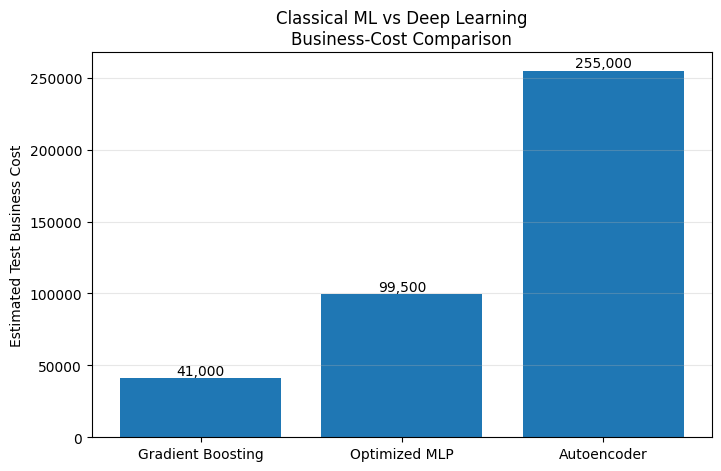

In [57]:
# ============================================================
# MODEL BUSINESS-COST COMPARISON
# ============================================================

cost_names = [
    "Gradient Boosting",
    "Optimized MLP",
    "Autoencoder"
]

cost_values = [
    classical_business_cost,
    mlp_test_optimized_cost,
    ae_test_business_cost
]


plt.figure(
    figsize=(8, 5)
)

bars = plt.bar(
    cost_names,
    cost_values
)

plt.ylabel(
    "Estimated Test Business Cost"
)

plt.title(
    "Classical ML vs Deep Learning\n"
    "Business-Cost Comparison"
)


for bar, cost in zip(
    bars,
    cost_values
):

    plt.text(
        bar.get_x()
        + bar.get_width() / 2,

        bar.get_height(),

        f"{cost:,.0f}",

        ha="center",
        va="bottom"
    )


plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

## 49. Export Cross-Model Comparison

The consolidated Classical Machine Learning versus Deep Learning comparison is exported as a CSV artifact for downstream reporting, deployment decisions, system integration, and project documentation.

The exported table preserves the evaluated operating point and test performance of:

- Gradient Boosting
- Optimized MLP
- Autoencoder

This artifact provides a single cross-model performance record containing predictive metrics, confusion-matrix outcomes, decision thresholds, and estimated business costs.

No additional training or threshold optimization is performed during this export stage.

In [58]:
# ============================================================
# SAVE CROSS-MODEL COMPARISON
# ============================================================

CROSS_MODEL_COMPARISON_PATH = os.path.join(
    MODELS_DIR,
    "final_ml_dl_model_comparison.csv"
)


model_comparison.to_csv(
    CROSS_MODEL_COMPARISON_PATH
)


print(
    "ML vs DL comparison saved to:"
)

print(
    CROSS_MODEL_COMPARISON_PATH
)

ML vs DL comparison saved to:
/content/models/final_ml_dl_model_comparison.csv


### Classical ML vs Deep Learning — Final Observation and Model Selection

The integrated evaluation demonstrates that the three modeling approaches provide distinct and complementary forms of predictive-maintenance intelligence.

### Primary Failure Predictor — Gradient Boosting

Gradient Boosting provides the strongest overall operational performance.

At its validation-selected threshold of **0.26**, it achieves:

- **Precision:** 0.9556
- **Recall:** 0.8431
- **F1-Score:** 0.8958
- **PR-AUC:** 0.9273
- **ROC-AUC:** 0.9766
- **False Positives:** 2
- **False Negatives:** 8
- **True Positives:** 43
- **Business Cost:** 41,000

Its combination of high precision, strong failure recall, excellent PR-AUC, and extremely low false-positive count makes it the most operationally efficient model under the established cost assumptions.

### High-Sensitivity Supervised Signal — MLP

The MLP provides a different operational strength.

At its validation-selected threshold of **0.36**, it achieves:

- **Recall:** 0.9020
- **False-Negative Rate:** 0.0980
- **True Positives:** 46
- **False Negatives:** 5

The MLP therefore detects **46 of the 51 actual machine failures**, compared with **43** detected by Gradient Boosting.

However, this higher sensitivity generates **149 false-positive alerts**, resulting in an estimated business cost of **99,500**.

The MLP is therefore valuable as a **high-sensitivity supervised failure-risk signal**, but it does not replace Gradient Boosting as the primary operational predictor under the current cost model.

### Complementary Unsupervised Signal — Autoencoder

The Autoencoder provides an independent reconstruction-based measure of deviation from learned healthy operating behavior.

Its standalone failure-detection performance is substantially weaker, detecting only **5 of the 51 failures** and producing a business cost of **255,000**.

Accordingly, the Autoencoder should not be treated as a competing primary failure classifier. Its appropriate role is as a **complementary unsupervised anomaly-detection component**.

### Selected Predictive-Maintenance Architecture

The resulting model architecture is:

**Gradient Boosting → Primary Failure-Risk Prediction**

**MLP → High-Sensitivity Supervised Failure Signal**

**Autoencoder → Complementary Unsupervised Anomaly Signal**

This architecture preserves the strongest operational predictor while retaining complementary supervised and unsupervised Deep Learning signals for downstream monitoring, risk analysis, deployment, and future model integration.